In [13]:
# librerias
from google.colab import drive
import numpy as np
import pandas as pd

In [14]:
drive.mount('/content/drive')


ruta_factor_riesgo='/content/drive/MyDrive/Portafolio/Prueba_1/data/Factores de Riesgo.xlsx'

factor_riesgo=pd.read_excel(ruta_factor_riesgo)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
factor_riesgo.head()

,Fecha,TA_Jur,DTF,IBR,IPC,Cuvr,Auvr
0,2008-01-01,0.087357,0.0912,0.095845,0.059970,0.100468,0.103624
1,2008-02-01,0.088923,0.0930,0.096665,0.063520,0.100283,0.103793
2,2008-03-01,0.089277,0.0959,0.098368,0.059260,0.102090,0.103267
3,2008-04-01,0.073719,0.0979,0.098304,0.057280,0.102489,0.104401
4,2008-05-01,0.073641,0.0959,0.098243,0.063943,0.102439,0.105267


Matriz de correlación de los datos modelados:


,DTF,IBR,IPC,Cuvr,Auvr,TA_Jur
DTF,1.000000,0.778631,0.501569,0.117276,0.146044,0.535922
IBR,0.778631,1.000000,0.462363,0.082690,0.053982,0.612074
IPC,0.501569,0.462363,1.000000,-0.021126,0.116980,0.279691
Cuvr,0.117276,0.082690,-0.021126,1.000000,-0.032266,-0.018643
Auvr,0.146044,0.053982,0.116980,-0.032266,1.000000,0.159463
TA_Jur,0.535922,0.612074,0.279691,-0.018643,0.159463,1.000000


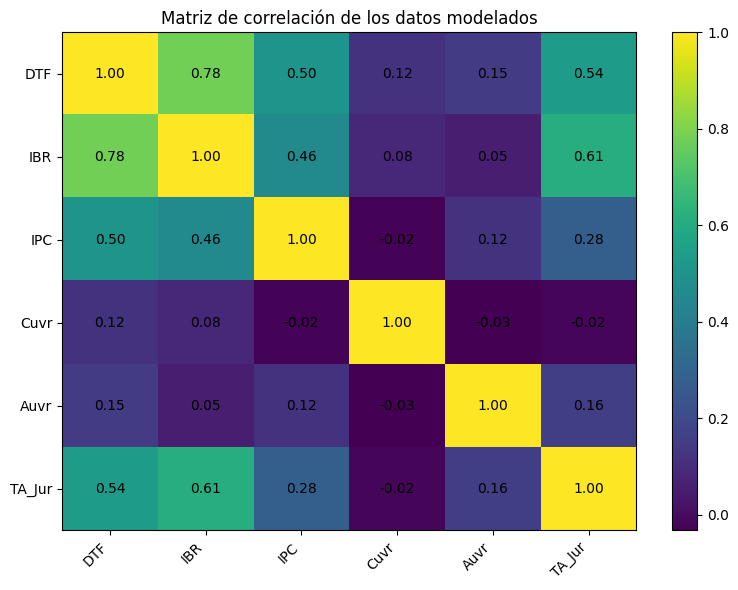

Archivos guardados en:
/content/drive/MyDrive/Portafolio/Prueba_1/data/matriz_correlacion_modelada.csv
/content/drive/MyDrive/Portafolio/Prueba_1/data/matriz_correlacion_modelada.xlsx
/content/drive/MyDrive/Portafolio/Prueba_1/data/matriz_correlacion_modelada.png


In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURACIÓN
# =========================================================
ruta_factor_riesgo = "/content/drive/MyDrive/Portafolio/Prueba_1/data/Factores de Riesgo.xlsx"
carpeta_salida = "/content/drive/MyDrive/Portafolio/Prueba_1/data"

FACTOR_COLS = ["DTF", "IBR", "IPC", "Cuvr", "Auvr", "TA_Jur"]

os.makedirs(carpeta_salida, exist_ok=True)

ruta_csv = os.path.join(carpeta_salida, "matriz_correlacion_modelada.csv")
ruta_excel = os.path.join(carpeta_salida, "matriz_correlacion_modelada.xlsx")
ruta_png = os.path.join(carpeta_salida, "matriz_correlacion_modelada.png")

# =========================================================
# FUNCIÓN PARA FECHAS
# =========================================================
def convertir_fecha_excel(serie):
    s = serie.copy()

    if pd.api.types.is_datetime64_any_dtype(s):
        return pd.to_datetime(s, errors="coerce")

    s_num = pd.to_numeric(s, errors="coerce")
    if s_num.notna().sum() > 0:
        return pd.to_datetime(s_num, unit="D", origin="1899-12-30", errors="coerce")

    return pd.to_datetime(s, errors="coerce")

# =========================================================
# CARGA Y LIMPIEZA
# =========================================================
factor_riesgo = pd.read_excel(ruta_factor_riesgo)
factor_riesgo = factor_riesgo.loc[:, ~factor_riesgo.columns.astype(str).str.contains(r"^Unnamed")]

fecha_col = None
for c in factor_riesgo.columns:
    if str(c).strip().lower() == "fecha":
        fecha_col = c
        break

if fecha_col is not None:
    factor_riesgo[fecha_col] = convertir_fecha_excel(factor_riesgo[fecha_col])
    factor_riesgo = factor_riesgo.sort_values(fecha_col).reset_index(drop=True)

X = factor_riesgo[FACTOR_COLS].apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

# =========================================================
# DATOS MODELADOS: PRIMERAS DIFERENCIAS
# =========================================================
datos_modelados = X.diff().dropna().reset_index(drop=True)

# Si quisieras correlación en niveles, reemplaza la línea anterior por:
# datos_modelados = X.copy()

# =========================================================
# MATRIZ DE CORRELACIÓN
# =========================================================
matriz_corr = datos_modelados.corr()

print("Matriz de correlación de los datos modelados:")
display(matriz_corr)

# =========================================================
# GUARDAR MATRIZ
# =========================================================
matriz_corr.to_csv(ruta_csv, index=True)
matriz_corr.to_excel(ruta_excel, index=True)

# =========================================================
# HEATMAP CON MATPLOTLIB
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(matriz_corr.values, aspect="auto")

ax.set_xticks(range(len(matriz_corr.columns)))
ax.set_yticks(range(len(matriz_corr.index)))
ax.set_xticklabels(matriz_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(matriz_corr.index)

# Etiquetas numéricas
for i in range(matriz_corr.shape[0]):
    for j in range(matriz_corr.shape[1]):
        ax.text(
            j, i,
            f"{matriz_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=10
        )

ax.set_title("Matriz de correlación de los datos modelados")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(ruta_png, dpi=300, bbox_inches="tight")
plt.show()

print("Archivos guardados en:")
print(ruta_csv)
print(ruta_excel)
print(ruta_png)

# Preparar Data para rolling

## Metodología de validación rolling expansiva

Para comparar de manera justa las distintas metodologías de modelación de los factores de riesgo, se implementará un esquema de **validación rolling expansiva** (*expanding window*). Este procedimiento permite evaluar el desempeño predictivo de cada modelo respetando la estructura temporal de los datos y evitando usar información futura en el entrenamiento.

### Idea general

Sea \( T \) el número total de observaciones disponibles. En este caso, se cuenta con \( T = 148 \) registros históricos por factor de riesgo. Se define una ventana inicial de entrenamiento de tamaño \( m = 100 \).

A partir de esta ventana inicial, se construyen sucesivos cortes temporales de la siguiente forma:

- En el primer corte, se usan las observaciones \( 1, 2, \dots, 100 \) para entrenar el modelo y se deja la observación \( 101 \) como valor a predecir.
- En el segundo corte, se usan las observaciones \( 1, 2, \dots, 101 \) para entrenar y se deja la observación \( 102 \) como valor a predecir.
- Este procedimiento continúa de manera sucesiva hasta agotar la muestra.

En términos generales, para cada paso \( s \), se tiene:

\[
$\text{Train}_s$ = \{1,2,$\dots$,m+s-1\}
\]

\[
$\text{Test}_s$ = \{m+s\}
\]

para \( s = 1,2,$\dots$,T-m \).

### Propósito de este esquema

La finalidad de esta metodología es evaluar la capacidad predictiva **fuera de muestra** de cada modelo. En cada iteración:

1. el modelo solo se ajusta con información disponible hasta ese momento;
2. se genera un pronóstico para la observación siguiente;
3. se compara la predicción con el valor realmente observado;
4. se repite el proceso expandiendo la muestra de entrenamiento.

De esta forma, se obtiene una secuencia de errores de predicción fuera de muestra, que posteriormente permitirá comparar metodologías mediante métricas como RMSE, MAE u otras que se definan.

### Estructura de los archivos para rolling

Para facilitar la implementación, se construirá un archivo Excel donde cada hoja representa un corte del esquema rolling expansivo. En cada hoja:

- estarán incluidas todas las observaciones disponibles hasta el punto de predicción;
- las observaciones de entrenamiento estarán marcadas como `train`;
- la observación inmediatamente siguiente estará marcada como `test`, ya que corresponde al dato que se desea predecir.

Por ejemplo:

- **Hoja 1**: observaciones 1 a 100 como `train`, observación 101 como `test`.
- **Hoja 2**: observaciones 1 a 101 como `train`, observación 102 como `test`.
- ...
- **Última hoja**: observaciones 1 a 147 como `train`, observación 148 como `test`.

### Ventaja de esta construcción

El archivo generado será una base común para todos los modelos. Luego, cada metodología hará su tratamiento específico sobre cada corte:

- el enfoque de normal multivariada transformará los datos según corresponda;
- el modelo VAR hará su propio tratamiento dinámico;
- el modelo de machine learning construirá sus variables rezagadas o transformaciones particulares.

Así, todos los modelos serán comparados bajo exactamente la misma estructura de validación temporal.

In [17]:
import pandas as pd
import numpy as np

# =========================================================
# PARÁMETROS
# =========================================================
VENTANA_INICIAL = 100

# Si tienes una columna de fecha y quieres ordenar por ella, colócala aquí.
# Si no, déjala en None y se respetará el orden actual del archivo.
FECHA_COL = "Fecha"   # por ejemplo: 'Fecha'

# Ruta donde se guardará el Excel con los splits rolling
RUTA_SALIDA = '/content/drive/MyDrive/Portafolio/Prueba_1/data/rolling_base_factores.xlsx'


# =========================================================
# FUNCIÓN
# =========================================================
def crear_excel_rolling_base(df, ventana_inicial=100, ruta_salida='rolling_base.xlsx', fecha_col=None):
    """
    Crea un Excel donde cada hoja es un split rolling expansivo:
      - Hoja 1: filas 1..ventana_inicial como train, fila ventana_inicial+1 como test
      - Hoja 2: filas 1..ventana_inicial+1 como train, fila ventana_inicial+2 como test
      - ...

    En cada hoja se incluyen:
      - todas las observaciones disponibles hasta ese corte
      - una columna indicando si la fila es TRAIN o TEST
      - una columna indicando si esa fila es la observación objetivo a predecir
    """
    df = df.copy()

    # Eliminar columnas tipo "Unnamed" si existen
    df = df.loc[:, ~df.columns.astype(str).str.contains(r'^Unnamed')]

    # Ordenar por fecha si aplica
    if fecha_col is not None and fecha_col in df.columns:
        df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')
        df = df.sort_values(fecha_col).reset_index(drop=True)
    else:
        df = df.reset_index(drop=True)

    n = len(df)

    if ventana_inicial >= n:
        raise ValueError(
            f"La ventana inicial ({ventana_inicial}) debe ser menor que el número de filas ({n})."
        )

    # Agregar identificador original de fila (1-based)
    df.insert(0, 'fila_original', np.arange(1, n + 1))

    resumen_splits = []

    with pd.ExcelWriter(ruta_salida, engine='openpyxl') as writer:

        split_id = 1

        # test_pos es el índice 0-based de la observación que se quiere predecir
        for test_pos in range(ventana_inicial, n):
            fila_test = test_pos + 1  # 1-based
            train_hasta = test_pos    # 1-based en términos humanos: hasta fila_test - 1

            # Tomamos desde la primera observación hasta la observación objetivo
            split_df = df.iloc[:test_pos + 1].copy()

            # Marcar tipo de fila
            split_df['tipo_registro'] = np.where(
                split_df['fila_original'] < fila_test,
                'train',
                'test'
            )

            split_df['usa_para_entrenar'] = np.where(split_df['tipo_registro'] == 'train', 1, 0)
            split_df['objetivo_a_predecir'] = np.where(split_df['tipo_registro'] == 'test', 1, 0)
            split_df['split_id'] = split_id

            # Reordenar columnas para que quede más claro
            columnas_control = [
                'split_id',
                'fila_original',
                'tipo_registro',
                'usa_para_entrenar',
                'objetivo_a_predecir'
            ]
            otras_columnas = [c for c in split_df.columns if c not in columnas_control]
            split_df = split_df[columnas_control + otras_columnas]

            # Nombre de la hoja
            nombre_hoja = f'split_{split_id:03d}'

            # Guardar hoja
            split_df.to_excel(writer, sheet_name=nombre_hoja, index=False)

            # Guardar resumen
            resumen_splits.append({
                'split_id': split_id,
                'hoja': nombre_hoja,
                'n_train': train_hasta,
                'fila_objetivo_test': fila_test
            })

            split_id += 1

        # Hoja final de resumen
        resumen_df = pd.DataFrame(resumen_splits)
        resumen_df.to_excel(writer, sheet_name='resumen_splits', index=False)

    print(f'Excel creado correctamente en:\n{ruta_salida}')
    print(f'Total de hojas rolling creadas: {len(resumen_splits)}')


# =========================================================
# EJECUCIÓN
# =========================================================
crear_excel_rolling_base(
    df=factor_riesgo,
    ventana_inicial=VENTANA_INICIAL,
    ruta_salida=RUTA_SALIDA,
    fecha_col=FECHA_COL
)

Excel creado correctamente en:
/content/drive/MyDrive/Portafolio/Prueba_1/data/rolling_base_factores.xlsx
Total de hojas rolling creadas: 48


# Normal multivariada

## Metodología propuesta para modelar los factores de riesgo

### 1. Recomendación metodológica

Para este proyecto se propone modelar los **cambios mensuales** de los factores de riesgo, y no sus niveles ni sus retornos logarítmicos directos. En particular, si

$$
X_t=
\begin{pmatrix}
\text{DTF}_t\\
\text{IBR}_t\\
\text{IPC}_t\\
\text{Cuvr}_t\\
\text{Auvr}_t\\
\text{TA_Jur}_t
\end{pmatrix},
$$

entonces se trabajará con la transformación

$$
\Delta X_t = X_t - X_{t-1}.
$$

Sobre esta variable transformada se plantea como modelo base:

$$
\Delta X_t \sim \mathcal{N}_k(\mu,\Sigma),
$$

donde:

- \($\mu$\) es el vector de medias de los cambios mensuales,
- \($\Sigma$\) es la matriz de covarianzas entre los cambios mensuales de los factores,
- \($k$\) es el número de factores de riesgo.

---

### 2. Justificación de la elección

La literatura revisada da soporte al uso de un enfoque **multivariado normal** para los factores de riesgo dentro del marco clásico de medición de riesgo. En particular, el enfoque RiskMetrics plantea que los retornos de los factores de riesgo pueden modelarse bajo normalidad condicional y que la volatilidad puede estimarse mediante esquemas tipo EWMA. Asimismo, la literatura de VaR basada en varianza-covarianza asume que los factores de riesgo siguen una distribución normal multivariada y que la matriz de covarianzas es el insumo central del modelo.

Sin embargo, en este proyecto los datos disponibles no corresponden a precios de activos transables ni a precios de bonos cupón cero, sino a series como **DTF, IBR, IPC, Cuvr, Auvr y TA\_Jur**, observadas mensualmente. Por ello, aunque RiskMetrics utiliza **retornos logarítmicos** cuando los factores son precios, y en el caso de renta fija formula el problema a partir de bonos cupón cero y tasas continuamente compuestas, esa estructura no coincide exactamente con la naturaleza de la base disponible en este ejercicio.

Por esta razón, resulta más razonable trabajar directamente con las **primeras diferencias** de las tasas o factores:

$$
\Delta X_t = X_t - X_{t-1},
$$

ya que:

1. preservan la interpretación económica natural de cada factor;
2. evitan imponer una transformación logarítmica sobre variables que no son precios;
3. permiten aplicar de manera directa una estructura de dependencia conjunta mediante una matriz de covarianzas;
4. son coherentes con el objetivo práctico del proyecto, que es simular trayectorias futuras de factores de riesgo para alimentar el cálculo financiero del NII y del EaR.

En otras palabras, se conserva la idea central de la metodología varianza-covarianza —modelar conjuntamente los movimientos de los factores mediante una distribución multivariada y su matriz de covarianzas—, pero adaptada a la naturaleza de los datos efectivamente observados.

---

### 3. Estimación de parámetros

Dado un conjunto de observaciones históricas \($\Delta X_2,\dots,\Delta X_T$\), se estimarán:

#### Media muestral
$$
\hat{\mu}=\frac{1}{T-1}\sum_{t=2}^{T}\Delta X_t
$$

#### Matriz de covarianzas muestral
$$
\hat{\Sigma}=\frac{1}{T-2}\sum_{t=2}^{T}(\Delta X_t-\hat{\mu})(\Delta X_t-\hat{\mu})^\top
$$

Como extensión, también puede considerarse una estimación tipo **EWMA** para la matriz de covarianzas, con el fin de dar mayor peso a las observaciones recientes y capturar mejor cambios en volatilidad.

---

### 4. Simulación de escenarios

Una vez estimados \($\hat{\mu}$\) y \($\hat{\Sigma}$\), se generarán escenarios futuros para los cambios mensuales de los factores:

$$
\Delta X_{t+1}^{(s)} \sim \mathcal{N}_k(\hat{\mu},\hat{\Sigma}),
$$

para \($s=1,\dots,S$\), donde \($S$\) es el número de simulaciones.

Luego, los niveles futuros de los factores se reconstruyen de forma recursiva como:

$$
X_{t+1}^{(s)} = X_t + \Delta X_{t+1}^{(s)},
$$

$$
X_{t+2}^{(s)} = X_{t+1}^{(s)} + \Delta X_{t+2}^{(s)},
$$

y así sucesivamente hasta completar el horizonte deseado.

---

### 5. Uso dentro del proyecto

Cada trayectoria simulada de los factores de riesgo será utilizada como entrada del modelo financiero del balance. Con ello se obtendrán trayectorias del NII mensual y anual, a partir de las cuales se calcularán medidas de riesgo como el **Earnings at Risk (EaR)**.

---

### 6. Comparación con otras metodologías

Esta metodología se utilizará como un **modelo base o benchmark**. Posteriormente, podrá compararse con otros enfoques, como VAR o modelos de machine learning, mediante un esquema de validación **rolling expansiva**, evaluando el desempeño predictivo fuera de muestra.

---

### 7. Conclusión metodológica

En síntesis, se propone modelar los **cambios mensuales de los factores de riesgo mediante una distribución normal multivariada**, estimando su dependencia conjunta a través de una matriz de covarianzas. Esta decisión mantiene el espíritu del enfoque clásico varianza-covarianza de la literatura de riesgo, pero se adapta de forma más apropiada a la naturaleza de los datos disponibles en este proyecto.

In [18]:
import pandas as pd
import numpy as np
import os

# =========================================================
# 0. CONFIGURACIÓN
# =========================================================
RUTA_ROLLING = "/content/drive/MyDrive/Portafolio/Prueba_1/data/rolling_base_factores.xlsx"

# Si quieres fijar manualmente las columnas de factores, descomenta esta línea:
FACTOR_COLS = ['DTF', 'IBR', 'IPC', 'Cuvr', 'Auvr', 'TA_Jur']


# Si quieres guardar resultados en Excel, deja una ruta aquí.
# Si no quieres guardar, pon GUARDA_RESULTADOS = False
GUARDA_RESULTADOS = True
RUTA_SALIDA = "/content/drive/MyDrive/Portafolio/Prueba_1/data/resultados_validacion_normal_multivariada.xlsx"


# =========================================================
# 1. FUNCIONES AUXILIARES
# =========================================================
def obtener_hojas_split(ruta_excel):
    """
    Devuelve únicamente las hojas tipo split_XXX
    """
    xls = pd.ExcelFile(ruta_excel, engine="openpyxl")
    hojas = [h for h in xls.sheet_names if h.lower().startswith("split_")]
    if not hojas:
        raise ValueError("No se encontraron hojas tipo 'split_XXX' en el archivo.")
    return hojas


def detectar_factor_cols(df, factor_cols=None):
    """
    Detecta columnas de factores excluyendo las columnas de control del rolling.
    Si factor_cols se pasa manualmente, valida que existan.
    """
    control_cols = {
        "split_id",
        "fila_original",
        "tipo_registro",
        "usa_para_entrenar",
        "objetivo_a_predecir"
    }

    if factor_cols is not None:
        faltantes = [c for c in factor_cols if c not in df.columns]
        if faltantes:
            raise ValueError(f"Estas columnas no existen en el split: {faltantes}")
        return factor_cols

    cols_candidatas = [c for c in df.columns if c not in control_cols]

    # Nos quedamos con columnas numéricas
    factor_cols_detectadas = []
    for c in cols_candidatas:
        try:
            serie = pd.to_numeric(df[c], errors="coerce")
            # aceptamos la columna si tiene al menos algún dato numérico
            if serie.notna().sum() > 0:
                factor_cols_detectadas.append(c)
        except Exception:
            pass

    if not factor_cols_detectadas:
        raise ValueError("No se detectaron columnas numéricas de factores.")
    return factor_cols_detectadas


def entrenar_y_predecir_split_normal(df_split, factor_cols):
    """
    Para una hoja split:
    1) toma train y test
    2) construye diferencias SOLO con train
    3) estima mu y Sigma del modelo normal multivariado
    4) usa como pronóstico puntual de Delta X_{t+1} la media muestral mu_hat
    5) reconstruye el nivel pronosticado
    """
    df = df_split.copy()

    # Estandarizar tipo_registro por seguridad
    df["tipo_registro"] = df["tipo_registro"].astype(str).str.strip().str.lower()

    # Orden temporal
    df = df.sort_values("fila_original").reset_index(drop=True)

    train_df = df[df["tipo_registro"] == "train"].copy()
    test_df = df[df["tipo_registro"] == "test"].copy()

    if train_df.empty:
        raise ValueError("No hay observaciones de entrenamiento en este split.")
    if len(test_df) != 1:
        raise ValueError("Cada split debe tener exactamente una observación de test.")

    # Convertir factores a numéricos
    X_train = train_df[factor_cols].apply(pd.to_numeric, errors="coerce")
    X_test = test_df[factor_cols].apply(pd.to_numeric, errors="coerce")

    if X_train.isna().any().any():
        raise ValueError("Hay valores faltantes/no numéricos en train.")
    if X_test.isna().any().any():
        raise ValueError("Hay valores faltantes/no numéricos en test.")

    # Primeras diferencias en train
    dX_train = X_train.diff().dropna()

    if len(dX_train) < 1:
        raise ValueError("No hay suficientes observaciones para calcular diferencias en train.")

    # Estimación del modelo:
    # Delta X_t ~ N_k(mu, Sigma)
    mu_hat = dX_train.mean()
    Sigma_hat = dX_train.cov()

    # Último nivel observado en train
    ultimo_nivel_train = X_train.iloc[-1]

    # Pronóstico puntual one-step-ahead:
    # E[Delta X_{t+1}] = mu_hat
    pred_diff = mu_hat.copy()
    pred_level = ultimo_nivel_train + pred_diff

    # Observado real
    real_level = X_test.iloc[0]
    real_diff = real_level - ultimo_nivel_train

    # Error
    error = real_level - pred_level

    # Metadatos
    fila_test = int(test_df["fila_original"].iloc[0])
    n_train = len(train_df)

    resultado = {
        "split_id": int(df["split_id"].iloc[0]),
        "n_train": n_train,
        "fila_test": fila_test
    }

    # Guardar por factor
    for col in factor_cols:
        resultado[f"ultimo_train_{col}"] = ultimo_nivel_train[col]
        resultado[f"pred_diff_{col}"] = pred_diff[col]
        resultado[f"real_diff_{col}"] = real_diff[col]
        resultado[f"pred_level_{col}"] = pred_level[col]
        resultado[f"real_level_{col}"] = real_level[col]
        resultado[f"error_{col}"] = error[col]

    return resultado, mu_hat, Sigma_hat


def calcular_metricas(resultados_df, factor_cols):
    """
    Calcula RMSE y MAE por factor, y además un agregado global
    usando los errores en nivel.
    """
    filas_metricas = []

    todos_errores = []

    for col in factor_cols:
        errores = resultados_df[f"error_{col}"].astype(float).values
        rmse = np.sqrt(np.mean(errores ** 2))
        mae = np.mean(np.abs(errores))

        filas_metricas.append({
            "factor": col,
            "RMSE": rmse,
            "MAE": mae
        })

        todos_errores.extend(errores.tolist())

    todos_errores = np.array(todos_errores, dtype=float)
    rmse_global = np.sqrt(np.mean(todos_errores ** 2))
    mae_global = np.mean(np.abs(todos_errores))

    filas_metricas.append({
        "factor": "GLOBAL",
        "RMSE": rmse_global,
        "MAE": mae_global
    })

    return pd.DataFrame(filas_metricas)


# =========================================================
# 2. LEER ARCHIVO Y OBTENER HOJAS
# =========================================================
if not os.path.exists(RUTA_ROLLING):
    raise FileNotFoundError(f"No existe el archivo: {RUTA_ROLLING}")

hojas_split = obtener_hojas_split(RUTA_ROLLING)

# Leer la primera hoja para detectar factores
df_ejemplo = pd.read_excel(RUTA_ROLLING, sheet_name=hojas_split[0], engine="openpyxl")
factor_cols_final = detectar_factor_cols(df_ejemplo, FACTOR_COLS)

print("Columnas de factores usadas:")
print(factor_cols_final)
print(f"\nNúmero de ventanas rolling encontradas: {len(hojas_split)}")


# =========================================================
# 3. ENTRENAMIENTO Y VALIDACIÓN EN CADA VENTANA
# =========================================================
resultados = []
mus = {}
sigmas = {}

for hoja in hojas_split:
    df_split = pd.read_excel(RUTA_ROLLING, sheet_name=hoja, engine="openpyxl")

    try:
        resultado_split, mu_hat, Sigma_hat = entrenar_y_predecir_split_normal(
            df_split=df_split,
            factor_cols=factor_cols_final
        )

        resultado_split["hoja"] = hoja
        resultados.append(resultado_split)

        mus[hoja] = mu_hat
        sigmas[hoja] = Sigma_hat

    except Exception as e:
        print(f"Error en {hoja}: {e}")


# Consolidar resultados
resultados_df = pd.DataFrame(resultados).sort_values("split_id").reset_index(drop=True)

if resultados_df.empty:
    raise ValueError("No se pudo procesar ningún split correctamente.")


# =========================================================
# 4. MÉTRICAS
# =========================================================
metricas_df = calcular_metricas(resultados_df, factor_cols_final)

print("\n" + "="*70)
print("MÉTRICAS DE VALIDACIÓN - MODELO NORMAL MULTIVARIADO")
print("="*70)
print(metricas_df.to_string(index=False))


# =========================================================
# 5. TABLA RESUMEN DE PRONÓSTICOS
# =========================================================
cols_resumen = ["split_id", "hoja", "n_train", "fila_test"]

for col in factor_cols_final:
    cols_resumen += [
        f"pred_level_{col}",
        f"real_level_{col}",
        f"error_{col}"
    ]

print("\n" + "="*70)
print("PRIMERAS FILAS DE RESULTADOS")
print("="*70)
print(resultados_df[cols_resumen].head().to_string(index=False))


# =========================================================
# 6. GUARDAR RESULTADOS OPCIONALMENTE
# =========================================================
if GUARDA_RESULTADOS:
    with pd.ExcelWriter(RUTA_SALIDA, engine="openpyxl") as writer:
        resultados_df.to_excel(writer, sheet_name="predicciones", index=False)
        metricas_df.to_excel(writer, sheet_name="metricas", index=False)

        # Guardar mu_hat de cada split
        filas_mu = []
        for hoja, mu_hat in mus.items():
            fila = {"hoja": hoja}
            for col in factor_cols_final:
                fila[f"mu_{col}"] = mu_hat[col]
            filas_mu.append(fila)
        pd.DataFrame(filas_mu).to_excel(writer, sheet_name="mu_por_split", index=False)

        # Guardar diagonales de Sigma como resumen
        filas_sigma = []
        for hoja, Sigma_hat in sigmas.items():
            fila = {"hoja": hoja}
            for col in factor_cols_final:
                fila[f"var_{col}"] = Sigma_hat.loc[col, col] if col in Sigma_hat.index else np.nan
            filas_sigma.append(fila)
        pd.DataFrame(filas_sigma).to_excel(writer, sheet_name="varianzas_por_split", index=False)

    print(f"\nResultados guardados en:\n{RUTA_SALIDA}")

Columnas de factores usadas:
['DTF', 'IBR', 'IPC', 'Cuvr', 'Auvr', 'TA_Jur']

Número de ventanas rolling encontradas: 48

MÉTRICAS DE VALIDACIÓN - MODELO NORMAL MULTIVARIADO
factor     RMSE      MAE
   DTF 0.001133 0.000800
   IBR 0.001993 0.001254
   IPC 0.003121 0.002178
  Cuvr 0.011296 0.008102
  Auvr 0.002814 0.002097
TA_Jur 0.001905 0.001257
GLOBAL 0.005069 0.002615

PRIMERAS FILAS DE RESULTADOS
 split_id      hoja  n_train  fila_test  pred_level_DTF  real_level_DTF  error_DTF  pred_level_IBR  real_level_IBR  error_IBR  pred_level_IPC  real_level_IPC  error_IPC  pred_level_Cuvr  real_level_Cuvr  error_Cuvr  pred_level_Auvr  real_level_Auvr  error_Auvr  pred_level_TA_Jur  real_level_TA_Jur  error_TA_Jur
        1 split_001      100        101        0.066251          0.0683   0.002049        0.066156        0.071646   0.005490        0.079511        0.081972   0.002461         0.079952         0.079430   -0.000522         0.085484         0.085849    0.000365           0.041118    

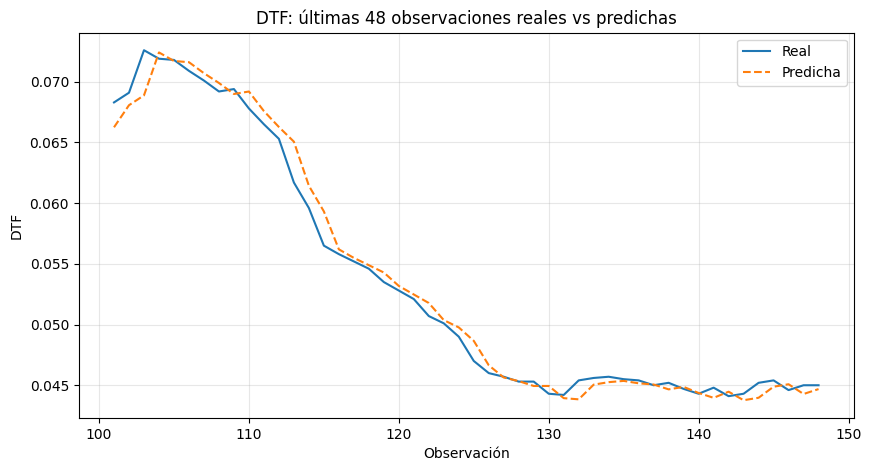

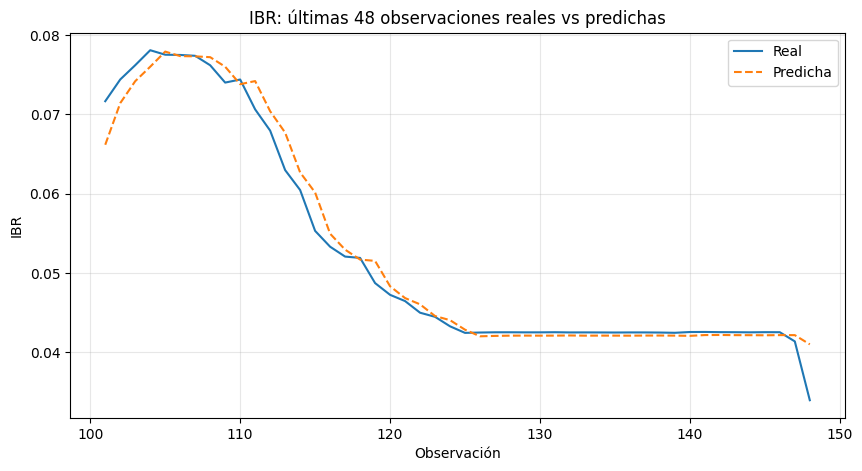

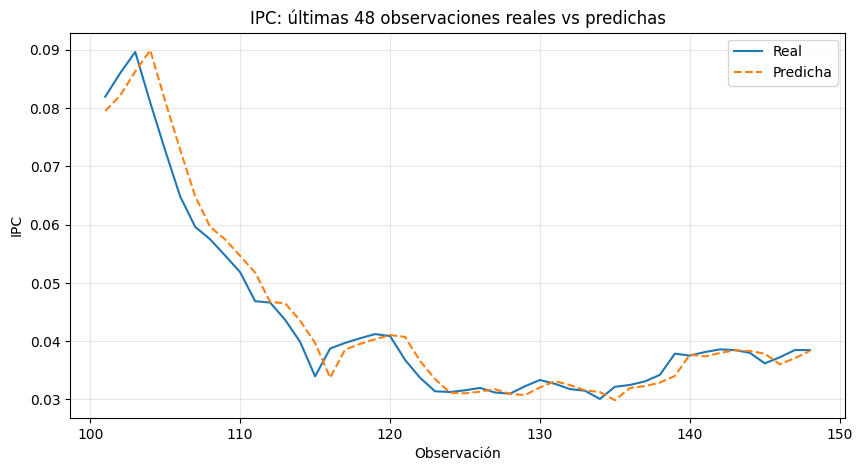

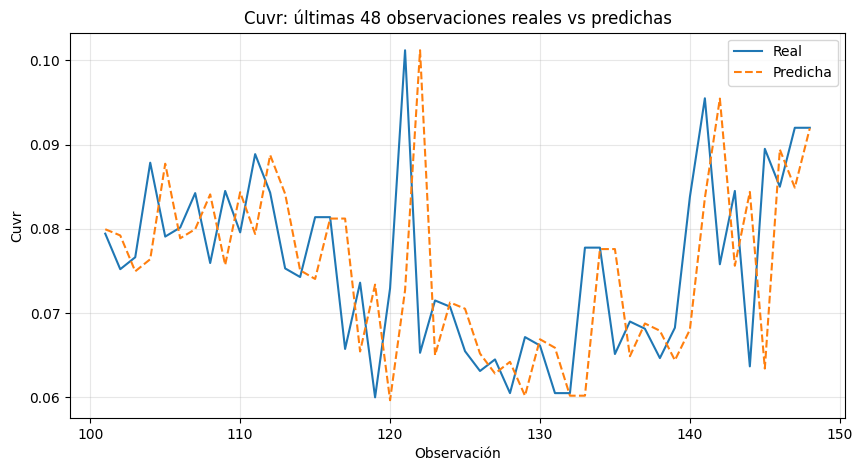

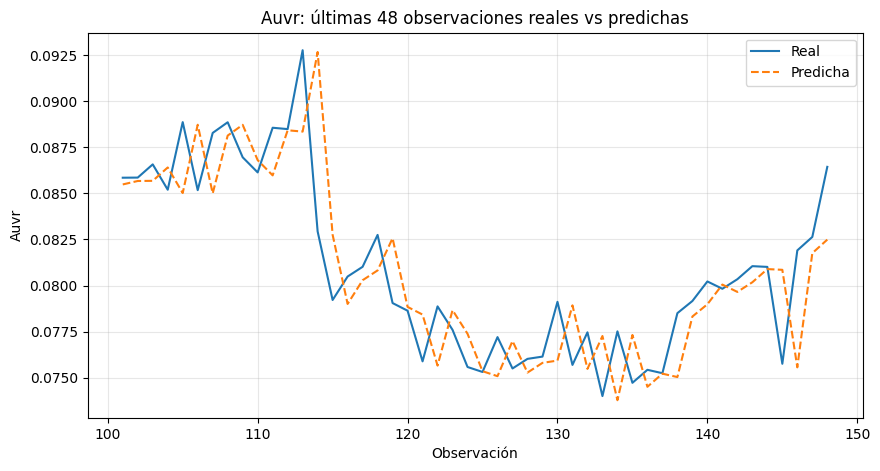

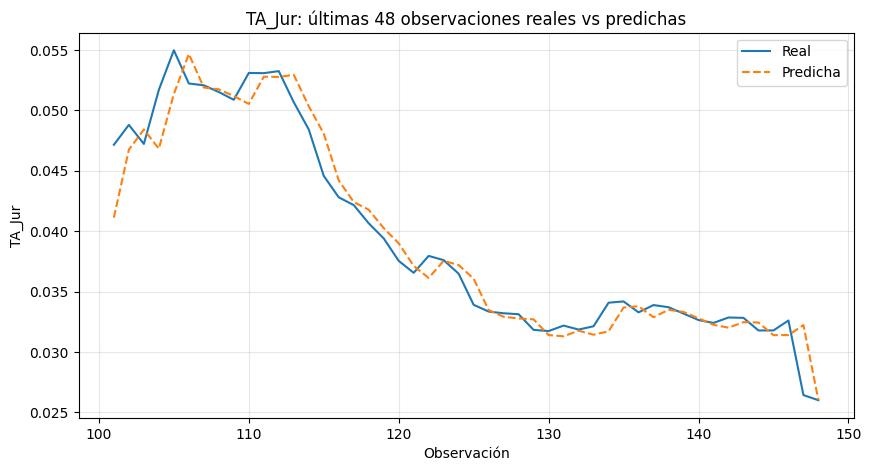

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. CARGAR RESULTADOS SI NO ESTÁN EN MEMORIA
# =========================================================
# Si ya tienes resultados_df y factor_cols_final en memoria, puedes saltarte esta parte.

try:
    resultados_df
    factor_cols_final
except NameError:
    RUTA_RESULTADOS = "/content/drive/MyDrive/Portafolio/Prueba_1/data/resultados_validacion_normal_multivariada.xlsx"
    resultados_df = pd.read_excel(RUTA_RESULTADOS, sheet_name="predicciones")

    # Detectar factores automáticamente a partir de columnas pred_level_
    factor_cols_final = [
        c.replace("pred_level_", "")
        for c in resultados_df.columns
        if c.startswith("pred_level_")
    ]

# =========================================================
# 2. ORDENAR Y QUEDARSE CON LAS ÚLTIMAS 48 OBSERVACIONES
# =========================================================
resultados_plot = resultados_df.sort_values("fila_test").tail(48).copy()

# =========================================================
# 3. GRAFICAR UNA FIGURA POR FACTOR
# =========================================================
for factor in factor_cols_final:
    plt.figure(figsize=(10, 5))

    # Serie real
    plt.plot(
        resultados_plot["fila_test"],
        resultados_plot[f"real_level_{factor}"],
        label="Real"
    )

    # Serie predicha en línea punteada
    plt.plot(
        resultados_plot["fila_test"],
        resultados_plot[f"pred_level_{factor}"],
        linestyle="--",
        label="Predicha"
    )

    plt.title(f"{factor}: últimas 48 observaciones reales vs predichas")
    plt.xlabel("Observación")
    plt.ylabel(factor)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# VAR

## Metodología implementada para la modelación y validación de los factores de riesgo

### 1. Objetivo

El objetivo es modelar la dinámica conjunta de los factores de riesgo para posteriormente generar **1000 escenarios mensuales a 12 meses** y utilizarlos como entrada en el cálculo del **NII** y del **EaR**.

Los factores considerados son:

\[
X_t=
\begin{pmatrix}
\text{DTF}_t\\
\text{IBR}_t\\
\text{IPC}_t\\
\text{Cuvr}_t\\
\text{Auvr}_t\\
\text{TA_Jur}_t
\end{pmatrix}
\]

con \($t=1,\dots,148$\).

---

### 2. Transformación de las series

Dado que varios factores en niveles presentan evidencia de no estacionariedad o resultados mixtos en las pruebas de raíz unitaria, la modelación se realiza sobre **primeras diferencias**:

$$
\Delta X_t = X_t - X_{t-1}.
$$

Esta transformación permite trabajar con series más cercanas a la estacionariedad, que es el supuesto natural para un modelo VAR.

---

### 3. Modelos candidatos evaluados

Se compararon tres enfoques predictivos:

1. **Benchmark ingenuo**
   $$
   \hat X_{t+1} = X_t
   $$
   o equivalentemente
   $$
   \widehat{\Delta X}_{t+1}=0.
   $$

2. **Modelo normal multivariado**
   $$
   \Delta X_t \sim \mathcal N_k(\mu,\Sigma),
   $$
   donde el pronóstico puntual a un paso es
   $$
   \widehat{\Delta X}_{t+1}=\hat\mu.
   $$

3. **Modelo VAR**
   $$
   \Delta X_t = c + A_1 \Delta X_{t-1} + \cdots + A_p \Delta X_{t-p} + u_t,
   $$
   con
   $$
   E(u_t)=0, \qquad \operatorname{Cov}(u_t)=\Sigma_u.
   $$

---

### 4. Esquema de validación

Para comparar los modelos se utilizó un esquema de **validación rolling expansiva**.

#### Estructura de cada split

- **Split 1:** observaciones \($1,\dots,100$\) para entrenar, observación \(101\) para validar.
- **Split 2:** observaciones \($1,\dots,101$\) para entrenar, observación \(102\) para validar.
- ...
- **Último split:** observaciones \($1,\dots,147$\) para entrenar, observación \(148\) para validar.

En cada ventana:

1. se toman las observaciones de entrenamiento;
2. se transforman a primeras diferencias;
3. se ajusta el modelo correspondiente;
4. se genera un pronóstico **one-step-ahead**;
5. se reconstruye el nivel pronosticado;
6. se compara con el valor observado.

---

### 5. Métricas de evaluación

El desempeño predictivo fuera de muestra se evaluó mediante:

#### Error cuadrático medio
$$
RMSE = \sqrt{\frac{1}{n}\sum_{t=1}^n e_t^2}
$$

#### Error absoluto medio
$$
MAE = \frac{1}{n}\sum_{t=1}^n |e_t|
$$

donde

$$
e_t = X_t - \hat X_t.
$$

Las métricas se calcularon por factor y también de forma global.

---

### 6. Selección del modelo final

A partir de la validación rolling expansiva se encontró que:

- el modelo **normal multivariado** no mejora de forma sistemática al benchmark ingenuo;
- el **benchmark ingenuo** resulta competitivo, lo cual indica una fuerte persistencia en niveles;
- el **VAR** presenta el mejor desempeño global y supera a los otros modelos en la mayoría de los factores.

En consecuencia, el modelo seleccionado como base para la simulación es un:

$$
\boxed{\text{VAR}(1)}
$$

ajustado sobre primeras diferencias.

---

### 7. Estimación final del modelo con toda la muestra

Una vez seleccionado el enfoque VAR, se reestimó el modelo utilizando toda la información disponible, es decir, las **148 observaciones históricas**.

La selección del rezago se realizó mediante criterios de información:

- AIC
- BIC
- HQIC
- FPE

Todos los criterios sugirieron:

$$
p=1.
$$

Por tanto, el modelo final adoptado fue:

$$
\Delta X_t = c + A_1 \Delta X_{t-1} + u_t.
$$

---

### 8. Validación de supuestos del VAR final

Sobre el modelo estimado con toda la muestra se validaron los siguientes aspectos:

#### a) Estacionariedad
Se aplicaron pruebas ADF y KPSS en niveles y en diferencias.

La evidencia empírica mostró que trabajar en diferencias es adecuado, ya que las series diferenciadas presentan comportamiento compatible con estacionariedad.

#### b) Estabilidad del sistema
Se verificó que el VAR(1) fuera estable, condición necesaria para realizar simulaciones recursivas consistentes en el horizonte de 12 meses.

#### c) Ruido blanco en los residuos
Se utilizó la prueba Portmanteau para verificar ausencia de autocorrelación residual. Los resultados apoyan que la dinámica lineal fue capturada razonablemente bien por el modelo.

#### d) Normalidad residual
Se aplicó una prueba omnibus de normalidad a los residuos. Los resultados rechazan la hipótesis de normalidad.

#### e) Heterocedasticidad condicional
Se aplicó una prueba ARCH por ecuación residual. Se encontró evidencia de posibles efectos ARCH en algunos factores, especialmente en **DTF** y **Cuvr**.

---

### 9. Implicación metodológica para la simulación

Los resultados anteriores permiten concluir que:

- la **estructura dinámica media** de los factores queda razonablemente bien representada por el **VAR(1)**;
- sin embargo, los residuos **no son gaussianos** y además presentan evidencia de **heterocedasticidad condicional** en algunos factores.

Por tanto, no resulta conveniente suponer innovaciones gaussianas i.i.d. del tipo:

$$
u_t \sim \mathcal N(0,\Sigma_u).
$$

En su lugar, para la simulación de escenarios se propone utilizar:

$$
\boxed{\text{bootstrap de residuos vectoriales del VAR}}
$$

---

### 10. Esquema de simulación propuesto

Sea el modelo final:

$$
\Delta X_t = c + A_1 \Delta X_{t-1} + u_t.
$$

La simulación de escenarios se realizará de forma recursiva:

#### Paso 1
Ajustar el VAR(1) con toda la muestra histórica y obtener los residuos estimados:

$$
\hat u_t = \Delta X_t - \widehat{\Delta X}_t.
$$
#### Paso 2
En cada paso de simulación, seleccionar aleatoriamente con reemplazo un **vector residual histórico completo** \(\hat u_t\).

#### Paso 3
Generar el siguiente cambio simulado:

$$
\Delta X_{T+1}^{(s)} = \hat c + \hat A_1 \Delta X_T + \hat u_{T+1}^{(s)}.
$$

#### Paso 4
Reconstruir el nivel:

$$
X_{T+1}^{(s)} = X_T + \Delta X_{T+1}^{(s)}.
$$

#### Paso 5
Repetir de forma recursiva hasta el horizonte \($h=12$\):

$$
\Delta X_{T+h}^{(s)} = \hat c + \hat A_1 \Delta X_{T+h-1}^{(s)} + \hat u_{T+h}^{(s)}.
$$

#### Paso 6
Repetir el procedimiento para:

$$
s=1,\dots,1000.
$$

Así se obtienen **1000 trayectorias mensuales de 12 meses** para todos los factores de riesgo.

---

### 11. Conclusión metodológica

En síntesis, la metodología implementada consiste en:

1. transformar los factores de riesgo a primeras diferencias;
2. comparar varios modelos mediante validación rolling expansiva;
3. seleccionar el **VAR(1)** como mejor modelo predictivo;
4. reestimarlo con toda la muestra disponible;
5. validar estacionariedad, estabilidad y comportamiento residual;
6. utilizar el VAR(1) como modelo de dinámica conjunta;
7. generar los escenarios futuros mediante **bootstrap de residuos del VAR**, en lugar de imponer normalidad gaussiana.

Esta estrategia permite conservar la estructura dinámica conjunta de los factores y, al mismo tiempo, relajar el supuesto de normalidad residual, lo que resulta más coherente con la evidencia empírica observada.

In [20]:
# =========================================================
# VALIDACIÓN ROLLING - MODELO VAR
# =========================================================

import os
import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

warnings.filterwarnings("ignore")

# =========================================================
# 0. CONFIGURACIÓN
# =========================================================
RUTA_ROLLING = "/content/drive/MyDrive/Portafolio/Prueba_1/data/rolling_base_factores.xlsx"

# Si quieres fijar manualmente las columnas de factores, descomenta:
FACTOR_COLS = ['DTF', 'IBR', 'IPC', 'Cuvr', 'Auvr', 'TA_Jur']


# Selección de rezagos
MAX_LAGS = 6          # máximo rezago a evaluar
CRITERION = "bic"     # "aic", "bic", "hqic", "fpe"
TREND = "c"           # "c" constante, "n" sin constante

# Guardado opcional
GUARDAR_RESULTADOS = True
RUTA_SALIDA = "/content/drive/MyDrive/Portafolio/Prueba_1/data/resultados_validacion_VAR.xlsx"


# =========================================================
# 1. FUNCIONES AUXILIARES
# =========================================================
def obtener_hojas_split(ruta_excel):
    xls = pd.ExcelFile(ruta_excel, engine="openpyxl")
    hojas = [h for h in xls.sheet_names if h.lower().startswith("split_")]
    if not hojas:
        raise ValueError("No se encontraron hojas tipo split_XXX en el archivo.")
    return hojas


def detectar_factor_cols(df, factor_cols=None):
    control_cols = {
        "split_id",
        "fila_original",
        "tipo_registro",
        "usa_para_entrenar",
        "objetivo_a_predecir"
    }

    if factor_cols is not None:
        faltantes = [c for c in factor_cols if c not in df.columns]
        if faltantes:
            raise ValueError(f"Estas columnas no existen en el archivo: {faltantes}")
        return factor_cols

    cols_candidatas = [c for c in df.columns if c not in control_cols]
    factor_cols_detectadas = []

    for c in cols_candidatas:
        serie = pd.to_numeric(df[c], errors="coerce")
        if serie.notna().sum() > 0:
            factor_cols_detectadas.append(c)

    if not factor_cols_detectadas:
        raise ValueError("No se detectaron columnas numéricas de factores.")
    return factor_cols_detectadas


def elegir_mejor_var(train_diff, max_lags=6, criterion="bic", trend="c"):
    """
    Ajusta VAR(p) para p=1,...,max_lags y selecciona el mejor según criterion.
    """
    n_obs, k = train_diff.shape

    # tope prudente de rezagos factibles
    p_max_factible = min(max_lags, max(1, n_obs // (k + 1)))

    mejor_fit = None
    mejor_p = None
    mejor_valor = np.inf

    for p in range(1, p_max_factible + 1):
        try:
            modelo = VAR(train_diff)
            fit = modelo.fit(p, trend=trend)

            valor = getattr(fit, criterion)
            if np.isfinite(valor) and valor < mejor_valor:
                mejor_valor = valor
                mejor_p = p
                mejor_fit = fit
        except Exception:
            continue

    if mejor_fit is None:
        raise ValueError("No fue posible ajustar ningún VAR válido en este split.")

    return mejor_fit, mejor_p, mejor_valor


def procesar_split_var(df_split, factor_cols, max_lags=6, criterion="bic", trend="c"):
    """
    Para una hoja split:
    1) toma train y test
    2) construye diferencias sobre train
    3) ajusta VAR sobre diferencias
    4) pronostica Delta X_{t+1}
    5) reconstruye nivel
    """
    df = df_split.copy()
    df["tipo_registro"] = df["tipo_registro"].astype(str).str.strip().str.lower()
    df = df.sort_values("fila_original").reset_index(drop=True)

    train_df = df[df["tipo_registro"] == "train"].copy()
    test_df = df[df["tipo_registro"] == "test"].copy()

    if train_df.empty:
        raise ValueError("No hay observaciones de entrenamiento.")
    if len(test_df) != 1:
        raise ValueError("Cada split debe tener exactamente una observación de test.")

    X_train = train_df[factor_cols].apply(pd.to_numeric, errors="coerce")
    X_test = test_df[factor_cols].apply(pd.to_numeric, errors="coerce")

    if X_train.isna().any().any():
        raise ValueError("Hay valores faltantes/no numéricos en train.")
    if X_test.isna().any().any():
        raise ValueError("Hay valores faltantes/no numéricos en test.")

    # Diferencias para el VAR
    dX_train = X_train.diff().dropna()

    if len(dX_train) < 8:
        raise ValueError("Muy pocas observaciones diferenciales para ajustar VAR.")

    mejor_fit, mejor_p, mejor_ic = elegir_mejor_var(
        train_diff=dX_train,
        max_lags=max_lags,
        criterion=criterion,
        trend=trend
    )

    # Pronóstico one-step-ahead sobre diferencias
    ultimos_rezagos = dX_train.values[-mejor_p:]
    pred_diff = mejor_fit.forecast(y=ultimos_rezagos, steps=1)[0]

    pred_diff = pd.Series(pred_diff, index=factor_cols)

    # Reconstrucción en niveles
    ultimo_nivel_train = X_train.iloc[-1]
    pred_level = ultimo_nivel_train + pred_diff

    real_level = X_test.iloc[0]
    real_diff = real_level - ultimo_nivel_train
    error = real_level - pred_level

    fila_test = int(test_df["fila_original"].iloc[0])
    n_train = len(train_df)
    split_id = int(df["split_id"].iloc[0])

    resultado = {
        "split_id": split_id,
        "n_train": n_train,
        "fila_test": fila_test,
        "lag_seleccionado": mejor_p,
        f"{criterion}_split": mejor_ic
    }

    for col in factor_cols:
        resultado[f"ultimo_train_{col}"] = float(ultimo_nivel_train[col])
        resultado[f"pred_diff_{col}"] = float(pred_diff[col])
        resultado[f"real_diff_{col}"] = float(real_diff[col])
        resultado[f"pred_level_{col}"] = float(pred_level[col])
        resultado[f"real_level_{col}"] = float(real_level[col])
        resultado[f"error_{col}"] = float(error[col])

    return resultado


def calcular_metricas(resultados_df, factor_cols):
    filas = []
    errores_globales = []

    for col in factor_cols:
        errores = resultados_df[f"error_{col}"].astype(float).values
        rmse = np.sqrt(np.mean(errores ** 2))
        mae = np.mean(np.abs(errores))

        filas.append({
            "factor": col,
            "RMSE": rmse,
            "MAE": mae
        })

        errores_globales.extend(errores.tolist())

    errores_globales = np.array(errores_globales, dtype=float)

    filas.append({
        "factor": "GLOBAL",
        "RMSE": np.sqrt(np.mean(errores_globales ** 2)),
        "MAE": np.mean(np.abs(errores_globales))
    })

    return pd.DataFrame(filas)


# =========================================================
# 2. LEER ARCHIVO Y DETECTAR HOJAS/COLUMNAS
# =========================================================
if not os.path.exists(RUTA_ROLLING):
    raise FileNotFoundError(f"No existe el archivo: {RUTA_ROLLING}")

hojas_split = obtener_hojas_split(RUTA_ROLLING)

df_ejemplo = pd.read_excel(RUTA_ROLLING, sheet_name=hojas_split[0], engine="openpyxl")
factor_cols_final = detectar_factor_cols(df_ejemplo, FACTOR_COLS)

print("Columnas de factores usadas:")
print(factor_cols_final)
print(f"\nNúmero de ventanas rolling: {len(hojas_split)}")


# =========================================================
# 3. ENTRENAMIENTO Y VALIDACIÓN EN CADA SPLIT
# =========================================================
resultados = []
errores_splits = []

for hoja in hojas_split:
    df_split = pd.read_excel(RUTA_ROLLING, sheet_name=hoja, engine="openpyxl")

    try:
        resultado = procesar_split_var(
            df_split=df_split,
            factor_cols=factor_cols_final,
            max_lags=MAX_LAGS,
            criterion=CRITERION,
            trend=TREND
        )
        resultado["hoja"] = hoja
        resultados.append(resultado)

    except Exception as e:
        errores_splits.append({"hoja": hoja, "error": str(e)})
        print(f"Error en {hoja}: {e}")

resultados_df = pd.DataFrame(resultados).sort_values("split_id").reset_index(drop=True)

if resultados_df.empty:
    raise ValueError("No se pudo procesar ningún split correctamente.")


# =========================================================
# 4. MÉTRICAS
# =========================================================
metricas_df = calcular_metricas(resultados_df, factor_cols_final)

print("\n" + "=" * 70)
print("MÉTRICAS DE VALIDACIÓN - MODELO VAR")
print("=" * 70)
print(metricas_df.to_string(index=False))


# =========================================================
# 5. RESUMEN DE REZAGOS SELECCIONADOS
# =========================================================
print("\n" + "=" * 70)
print("RESUMEN DE REZAGOS SELECCIONADOS")
print("=" * 70)
print(resultados_df["lag_seleccionado"].value_counts().sort_index().to_string())


# =========================================================
# 6. PRIMERAS FILAS DE RESULTADOS
# =========================================================
cols_resumen = ["split_id", "hoja", "n_train", "fila_test", "lag_seleccionado", f"{CRITERION}_split"]
for col in factor_cols_final:
    cols_resumen += [
        f"pred_level_{col}",
        f"real_level_{col}",
        f"error_{col}"
    ]

print("\n" + "=" * 70)
print("PRIMERAS FILAS DE RESULTADOS")
print("=" * 70)
print(resultados_df[cols_resumen].head().to_string(index=False))


# =========================================================
# 7. GUARDAR RESULTADOS
# =========================================================
if GUARDAR_RESULTADOS:
    with pd.ExcelWriter(RUTA_SALIDA, engine="openpyxl") as writer:
        resultados_df.to_excel(writer, sheet_name="predicciones", index=False)
        metricas_df.to_excel(writer, sheet_name="metricas", index=False)

        # resumen de rezagos
        resumen_lags = (
            resultados_df["lag_seleccionado"]
            .value_counts()
            .sort_index()
            .rename_axis("lag")
            .reset_index(name="frecuencia")
        )
        resumen_lags.to_excel(writer, sheet_name="lags_seleccionados", index=False)

        # errores por split, si existieron
        if errores_splits:
            pd.DataFrame(errores_splits).to_excel(writer, sheet_name="splits_con_error", index=False)

    print(f"\nResultados guardados en:\n{RUTA_SALIDA}")

Columnas de factores usadas:
['DTF', 'IBR', 'IPC', 'Cuvr', 'Auvr', 'TA_Jur']

Número de ventanas rolling: 48

MÉTRICAS DE VALIDACIÓN - MODELO VAR
factor     RMSE      MAE
   DTF 0.001003 0.000701
   IBR 0.001683 0.001040
   IPC 0.002894 0.001879
  Cuvr 0.010705 0.007759
  Auvr 0.002663 0.002124
TA_Jur 0.001849 0.001272
GLOBAL 0.004784 0.002463

RESUMEN DE REZAGOS SELECCIONADOS
lag_seleccionado
1    48

PRIMERAS FILAS DE RESULTADOS
 split_id      hoja  n_train  fila_test  lag_seleccionado  bic_split  pred_level_DTF  real_level_DTF  error_DTF  pred_level_IBR  real_level_IBR  error_IBR  pred_level_IPC  real_level_IPC  error_IPC  pred_level_Cuvr  real_level_Cuvr  error_Cuvr  pred_level_Auvr  real_level_Auvr  error_Auvr  pred_level_TA_Jur  real_level_TA_Jur  error_TA_Jur
        1 split_001      100        101                 1 -72.329487        0.068257          0.0683   0.000043        0.068058        0.071646   0.003587        0.079784        0.081972   0.002188         0.080445         

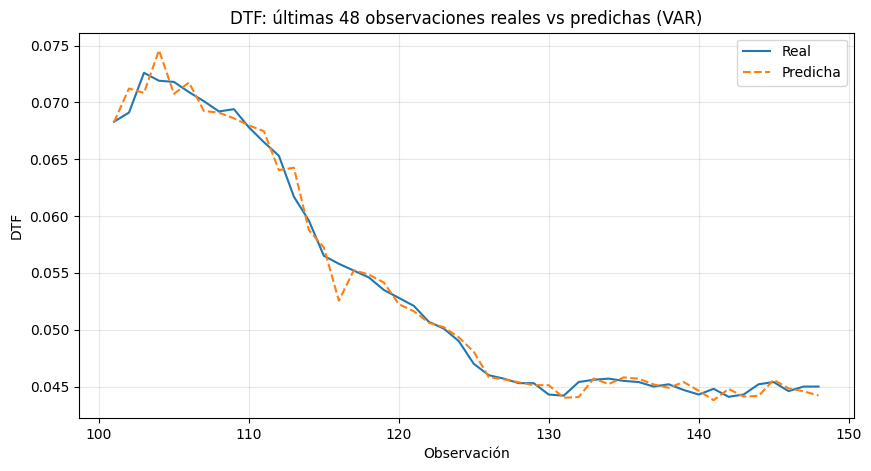

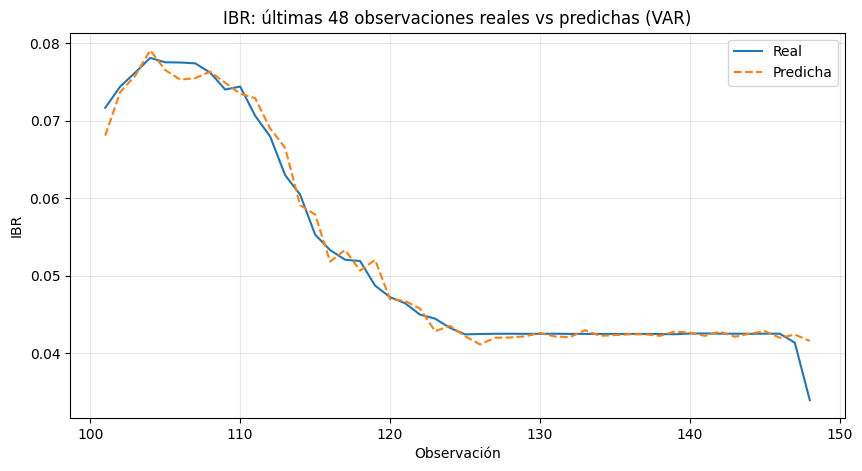

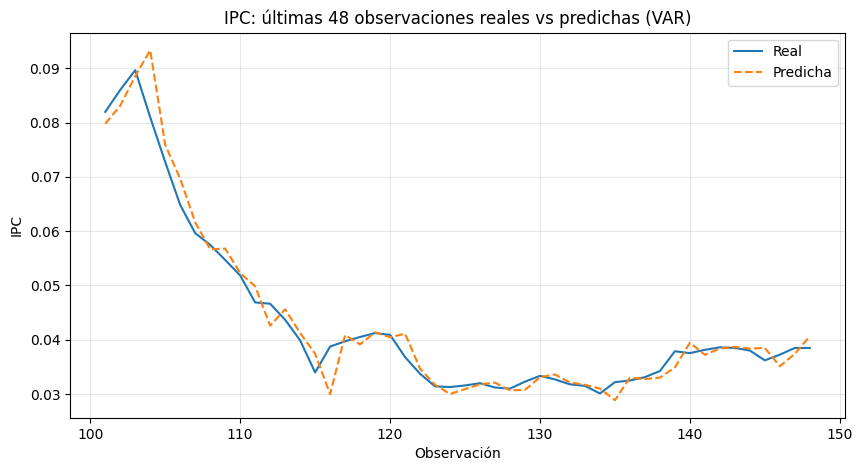

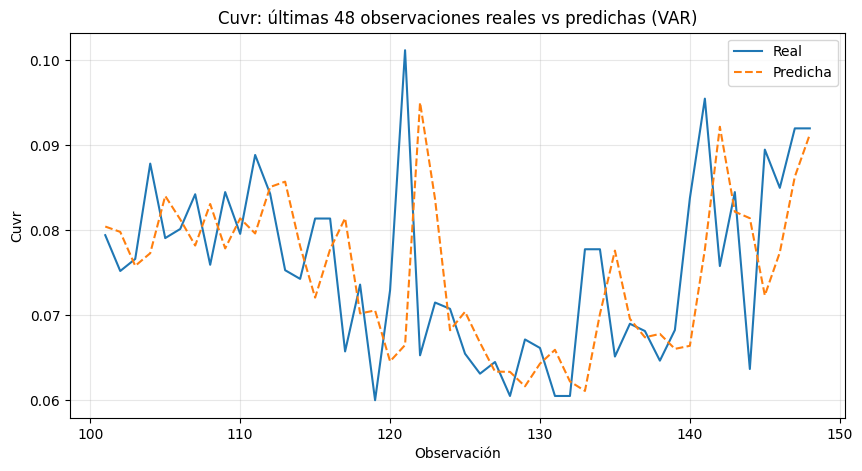

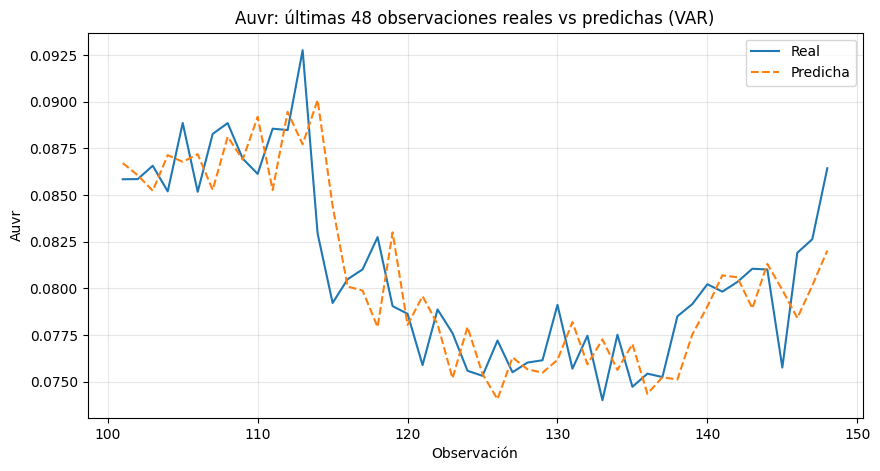

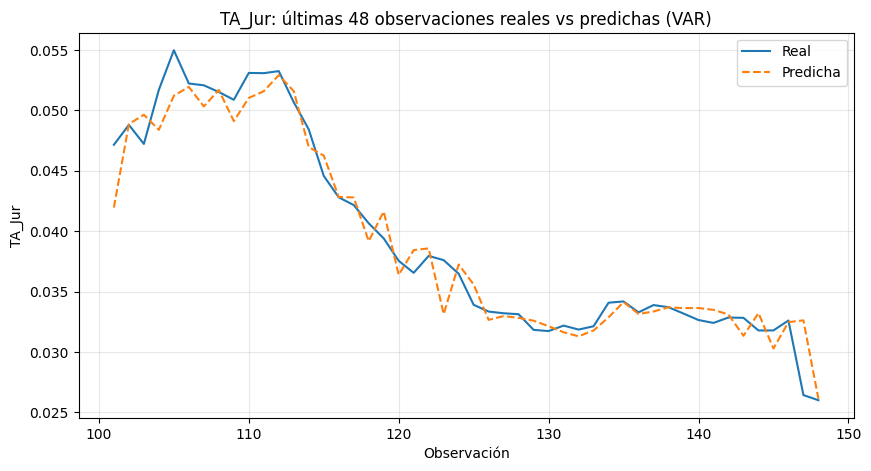

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. CARGAR RESULTADOS DEL VAR
# =========================================================
RUTA_RESULTADOS_VAR = "/content/drive/MyDrive/Portafolio/Prueba_1/data/resultados_validacion_VAR.xlsx"

resultados_df = pd.read_excel(RUTA_RESULTADOS_VAR, sheet_name="predicciones")

# Detectar factores automáticamente a partir de columnas pred_level_
factor_cols_final = [
    c.replace("pred_level_", "")
    for c in resultados_df.columns
    if c.startswith("pred_level_")
]

# =========================================================
# 2. ORDENAR Y TOMAR LAS ÚLTIMAS 48 OBSERVACIONES
# =========================================================
resultados_plot = resultados_df.sort_values("fila_test").tail(48).copy()

# =========================================================
# 3. GRAFICAR UNA FIGURA POR FACTOR
# =========================================================
for factor in factor_cols_final:
    plt.figure(figsize=(10, 5))

    # Serie real
    plt.plot(
        resultados_plot["fila_test"],
        resultados_plot[f"real_level_{factor}"],
        label="Real"
    )

    # Serie predicha en línea punteada
    plt.plot(
        resultados_plot["fila_test"],
        resultados_plot[f"pred_level_{factor}"],
        linestyle="--",
        label="Predicha"
    )

    plt.title(f"{factor}: últimas 48 observaciones reales vs predichas (VAR)")
    plt.xlabel("Observación")
    plt.ylabel(factor)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Supuestos del VAR

DIMENSIONES
Observaciones en niveles:      148
Observaciones en diferencias:  147
Número de factores:            6

ESTACIONARIEDAD
       serie test  estadistico       pvalor                             decision_5%
   DTF_nivel  ADF    -3.014097 3.359875e-02               Rechaza H0 (estacionaria)
   DTF_nivel KPSS     0.282666 1.000000e-01            No rechaza H0 (estacionaria)
    DTF_diff  ADF    -3.898761 2.043987e-03               Rechaza H0 (estacionaria)
    DTF_diff KPSS     0.172040 1.000000e-01            No rechaza H0 (estacionaria)
   IBR_nivel  ADF    -3.889455 2.113834e-03               Rechaza H0 (estacionaria)
   IBR_nivel KPSS     0.229501 1.000000e-01            No rechaza H0 (estacionaria)
    IBR_diff  ADF    -2.727216 6.944599e-02 No rechaza H0 (posible no estacionaria)
    IBR_diff KPSS     0.165297 1.000000e-01            No rechaza H0 (estacionaria)
   IPC_nivel  ADF    -2.628681 8.721322e-02 No rechaza H0 (posible no estacionaria)
   IPC_nivel KPSS     0.1436

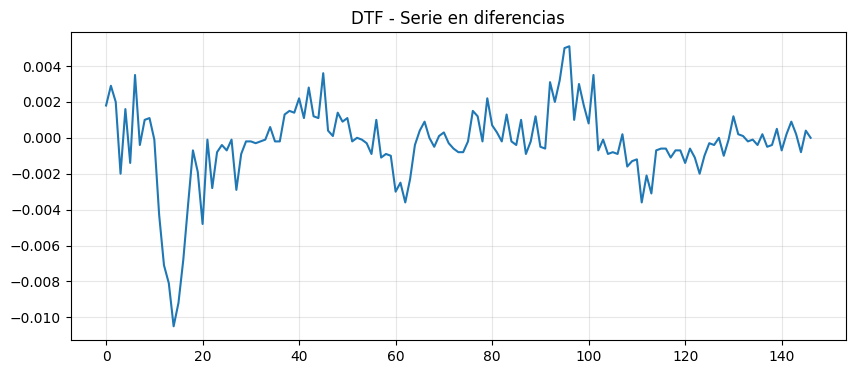

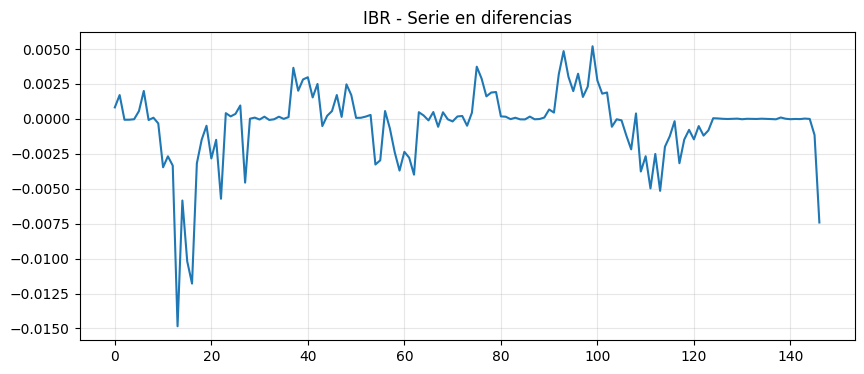

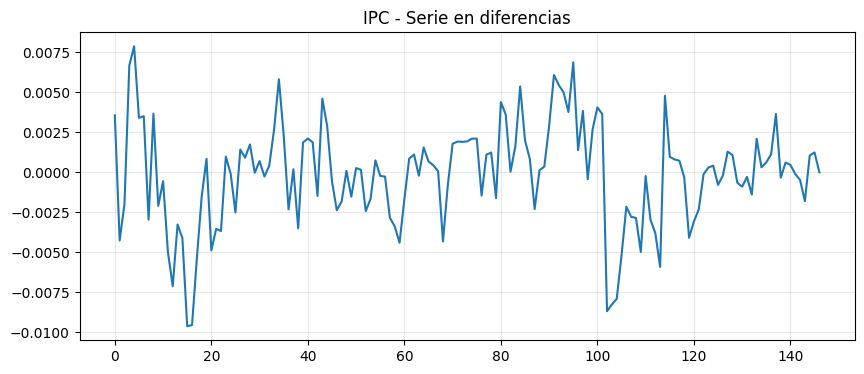

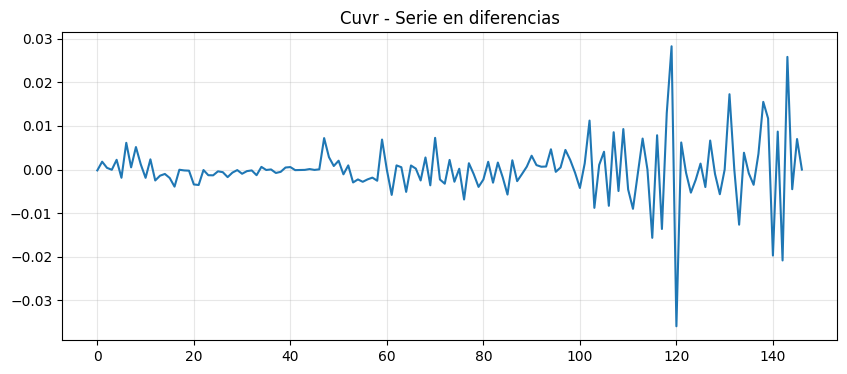

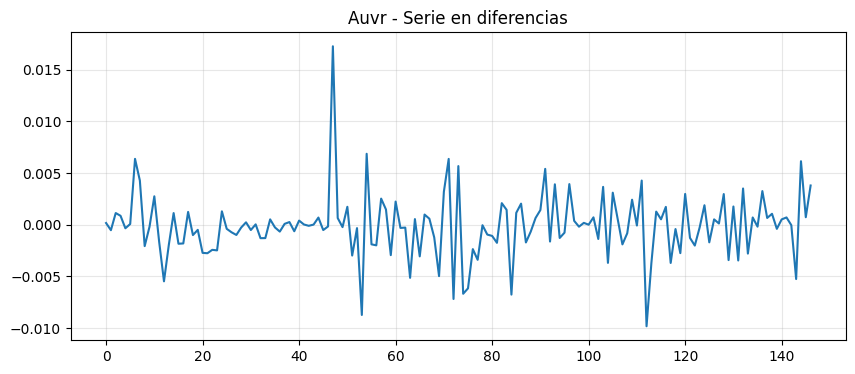

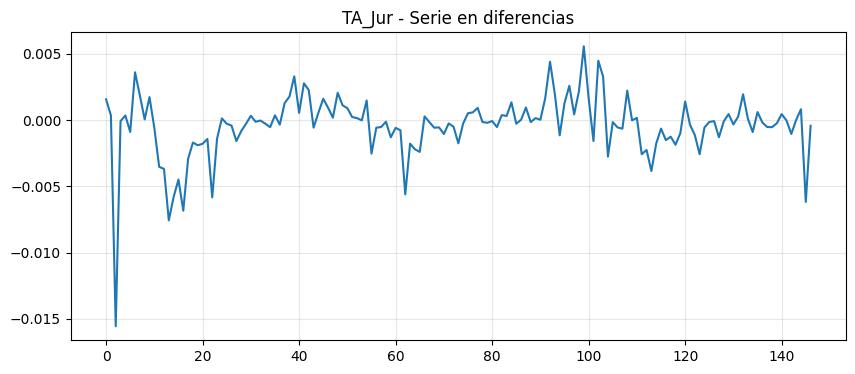

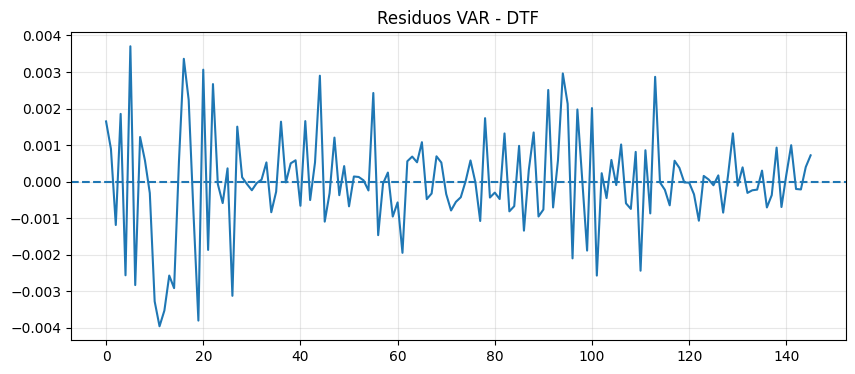

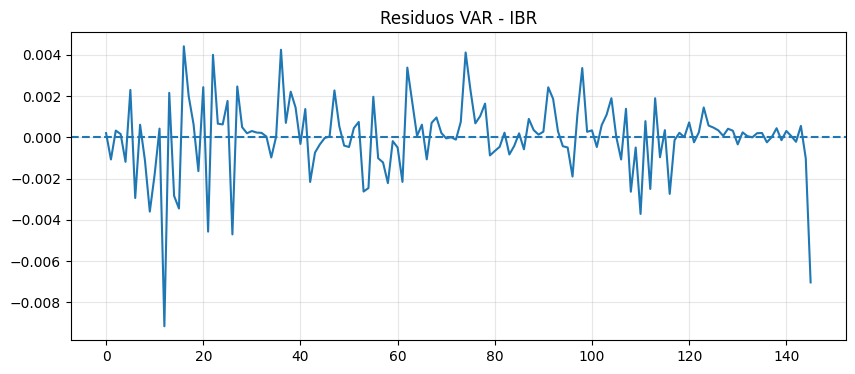

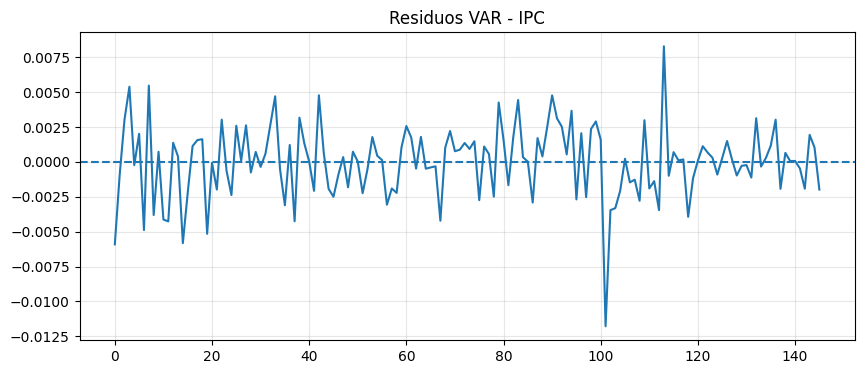

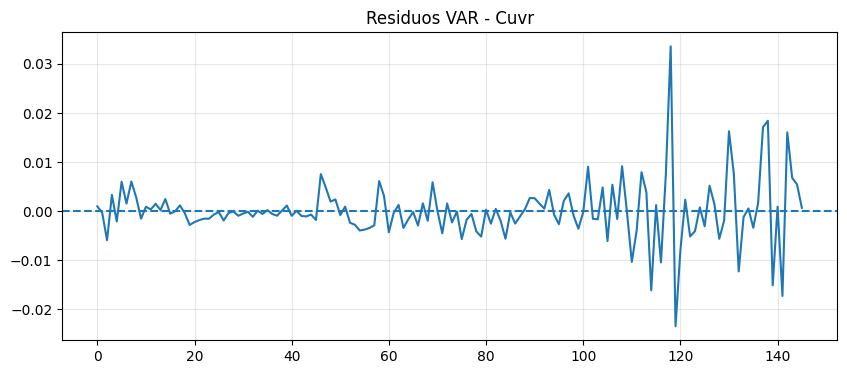

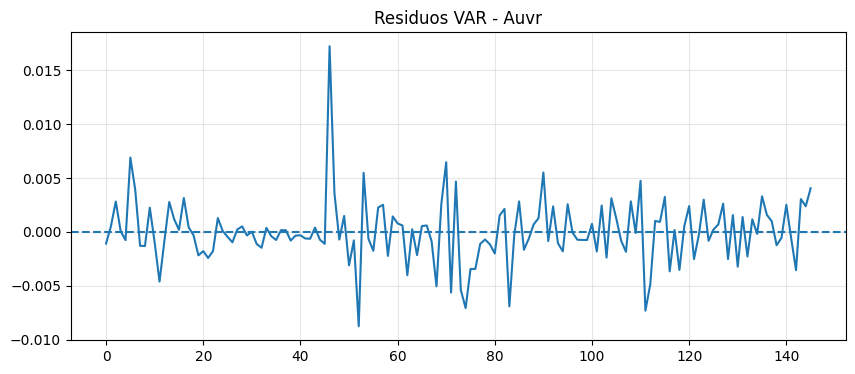

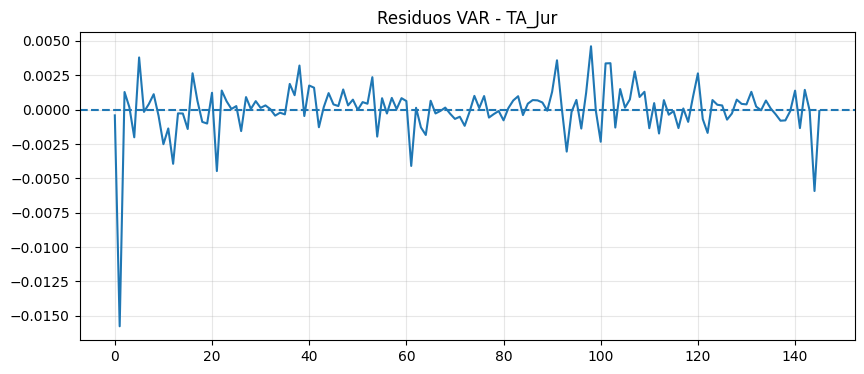


Archivo guardado en:
/content/drive/MyDrive/Portafolio/Prueba_1/data/validacion_supuestos_VAR_completo.xlsx


In [22]:
# =========================================================
# VALIDACIÓN DE SUPUESTOS DEL VAR CON TODA LA MUESTRA
# =========================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import het_arch

warnings.filterwarnings("ignore")

# =========================================================
# 0. CONFIGURACIÓN
# =========================================================
RUTA_FACTOR_RIESGO = "/content/drive/MyDrive/Portafolio/Prueba_1/data/Factores de Riesgo.xlsx"

# Si ya tienes factor_riesgo cargado, el código lo usa.
# Si no, lo lee desde Excel.
FACTOR_COLS = ['DTF', 'IBR', 'IPC', 'Cuvr', 'Auvr', 'TA_Jur']

MAX_LAGS = 6
CRITERION = "bic"   # 'aic', 'bic', 'hqic', 'fpe'
TREND = "c"         # 'c' constante, 'n' sin constante

GUARDAR_RESULTADOS = True
RUTA_SALIDA = "/content/drive/MyDrive/Portafolio/Prueba_1/data/validacion_supuestos_VAR_completo.xlsx"

# Número de rezagos para algunas pruebas de diagnóstico
NLAGS_WHITENESS = 12
NLAGS_ARCH = 12


# =========================================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# =========================================================
try:
    factor_riesgo
except NameError:
    factor_riesgo = pd.read_excel(RUTA_FACTOR_RIESGO)

df = factor_riesgo.copy()

# quitar columnas tipo Unnamed
df = df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed")]

# si existe una columna Fecha, la conservamos aparte solo para ordenar / referencia
fecha_col = None
for c in df.columns:
    if str(c).strip().lower() == "fecha":
        fecha_col = c
        break

if fecha_col is not None:
    df[fecha_col] = pd.to_datetime(df[fecha_col], errors="coerce")
    df = df.sort_values(fecha_col).reset_index(drop=True)

# Nos quedamos solo con factores
X = df[FACTOR_COLS].apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

# Diferencias
dX = X.diff().dropna().reset_index(drop=True)

print("=" * 70)
print("DIMENSIONES")
print("=" * 70)
print(f"Observaciones en niveles:      {X.shape[0]}")
print(f"Observaciones en diferencias:  {dX.shape[0]}")
print(f"Número de factores:            {X.shape[1]}")


# =========================================================
# 2. FUNCIONES AUXILIARES
# =========================================================
def ejecutar_adf(series, nombre):
    """
    ADF:
    H0: la serie tiene raíz unitaria (no estacionaria)
    """
    res = adfuller(series.dropna(), autolag="AIC")
    return {
        "serie": nombre,
        "test": "ADF",
        "estadistico": res[0],
        "pvalor": res[1],
        "lags_usados": res[2],
        "nobs": res[3],
        "cv_1%": res[4]["1%"],
        "cv_5%": res[4]["5%"],
        "cv_10%": res[4]["10%"],
        "decision_5%": "Rechaza H0 (estacionaria)" if res[1] < 0.05 else "No rechaza H0 (posible no estacionaria)"
    }


def ejecutar_kpss(series, nombre):
    """
    KPSS:
    H0: la serie es estacionaria
    """
    stat, pval, lags, crit = kpss(series.dropna(), regression="c", nlags="auto")
    return {
        "serie": nombre,
        "test": "KPSS",
        "estadistico": stat,
        "pvalor": pval,
        "lags_usados": lags,
        "nobs": len(series.dropna()),
        "cv_1%": crit["1%"],
        "cv_5%": crit["5%"],
        "cv_10%": crit["10%"],
        "decision_5%": "No rechaza H0 (estacionaria)" if pval >= 0.05 else "Rechaza H0 (posible no estacionaria)"
    }


def extraer_attr(obj, nombres, default=np.nan):
    """
    Intenta extraer el primer atributo disponible de una lista de nombres.
    """
    for n in nombres:
        if hasattr(obj, n):
            return getattr(obj, n)
    return default


# =========================================================
# 3. PRUEBAS DE ESTACIONARIEDAD
#    Se revisan niveles y diferencias
# =========================================================
resultados_estacionariedad = []

for col in FACTOR_COLS:
    # niveles
    resultados_estacionariedad.append(ejecutar_adf(X[col], f"{col}_nivel"))
    resultados_estacionariedad.append(ejecutar_kpss(X[col], f"{col}_nivel"))

    # diferencias
    resultados_estacionariedad.append(ejecutar_adf(dX[col], f"{col}_diff"))
    resultados_estacionariedad.append(ejecutar_kpss(dX[col], f"{col}_diff"))

estacionariedad_df = pd.DataFrame(resultados_estacionariedad)

print("\n" + "=" * 70)
print("ESTACIONARIEDAD")
print("=" * 70)
print(estacionariedad_df[["serie", "test", "estadistico", "pvalor", "decision_5%"]].to_string(index=False))


# =========================================================
# 4. SELECCIÓN DE REZAGO CON TODA LA MUESTRA
# =========================================================
modelo_var = VAR(dX)
ordenes = modelo_var.select_order(maxlags=MAX_LAGS, trend=TREND)

seleccion_lags_df = pd.DataFrame({
    "criterio": ["AIC", "BIC", "HQIC", "FPE"],
    "rezago_sugerido": [
        ordenes.aic,
        ordenes.bic,
        ordenes.hqic,
        ordenes.fpe
    ]
})

p_final = int(getattr(ordenes, CRITERION))

print("\n" + "=" * 70)
print("SELECCIÓN DE REZAGO")
print("=" * 70)
print(seleccion_lags_df.to_string(index=False))
print(f"\nRezago seleccionado por {CRITERION.upper()}: p = {p_final}")


# =========================================================
# 5. AJUSTE FINAL DEL VAR CON TODA LA MUESTRA
# =========================================================
fit_var = modelo_var.fit(p_final, trend=TREND)

print("\n" + "=" * 70)
print("RESUMEN DEL VAR AJUSTADO")
print("=" * 70)
print(fit_var.summary())


# =========================================================
# 6. ESTABILIDAD DEL VAR
# =========================================================
estable = fit_var.is_stable()
roots = fit_var.roots

estabilidad_df = pd.DataFrame({
    "raiz": roots,
    "modulo": np.abs(roots)
})

print("\n" + "=" * 70)
print("ESTABILIDAD")
print("=" * 70)
print(f"¿El VAR es estable?: {estable}")
print(estabilidad_df.to_string(index=False))


# =========================================================
# 7. DIAGNÓSTICO DE RESIDUOS
#    7.1 Ruido blanco (Portmanteau)
#    7.2 Normalidad
#    7.3 ARCH por ecuación
# =========================================================

# 7.1 Whiteness
white_res = fit_var.test_whiteness(nlags=NLAGS_WHITENESS, adjusted=True)

white_df = pd.DataFrame({
    "prueba": ["Portmanteau residual whiteness"],
    "estadistico": [extraer_attr(white_res, ["test_statistic", "statistic", "test_stat"])],
    "pvalor": [extraer_attr(white_res, ["pvalue", "p_value"])],
    "gl": [extraer_attr(white_res, ["df", "df_denom"])],
    "decision_5%": [
        "No rechaza H0 (residuos ~ ruido blanco)"
        if extraer_attr(white_res, ["pvalue", "p_value"], 0) >= 0.05
        else "Rechaza H0 (hay autocorrelación residual)"
    ]
})

# 7.2 Normalidad
norm_res = fit_var.test_normality()

normalidad_df = pd.DataFrame({
    "prueba": ["Normalidad residual omnibus"],
    "estadistico": [extraer_attr(norm_res, ["test_statistic", "statistic", "test_stat"])],
    "pvalor": [extraer_attr(norm_res, ["pvalue", "p_value"])],
    "gl": [extraer_attr(norm_res, ["df"])],
    "decision_5%": [
        "No rechaza H0 (residuos ~ normales)"
        if extraer_attr(norm_res, ["pvalue", "p_value"], 0) >= 0.05
        else "Rechaza H0 (no normalidad residual)"
    ]
})

# 7.3 ARCH por ecuación
arch_rows = []
for i, col in enumerate(FACTOR_COLS):
    resid_i = fit_var.resid[:, i] if isinstance(fit_var.resid, np.ndarray) else fit_var.resid[col].values
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(resid_i, nlags=NLAGS_ARCH)

    arch_rows.append({
        "serie_residual": col,
        "LM_stat": lm_stat,
        "LM_pvalor": lm_pvalue,
        "F_stat": f_stat,
        "F_pvalor": f_pvalue,
        "decision_5%": "No rechaza H0 (sin ARCH)" if lm_pvalue >= 0.05 else "Rechaza H0 (posible ARCH)"
    })

arch_df = pd.DataFrame(arch_rows)

print("\n" + "=" * 70)
print("RUIDO BLANCO")
print("=" * 70)
print(white_df.to_string(index=False))

print("\n" + "=" * 70)
print("NORMALIDAD DE RESIDUOS")
print("=" * 70)
print(normalidad_df.to_string(index=False))

print("\n" + "=" * 70)
print("ARCH EN RESIDUOS")
print("=" * 70)
print(arch_df.to_string(index=False))


# =========================================================
# 8. MATRIZ DE COVARIANZA RESIDUAL Y PARÁMETROS
# =========================================================
sigma_u_df = pd.DataFrame(fit_var.sigma_u, index=FACTOR_COLS, columns=FACTOR_COLS)

parametros_rows = []
for eq_name in FACTOR_COLS:
    eq_params = fit_var.params[eq_name] if hasattr(fit_var.params, "columns") else None

if hasattr(fit_var.params, "reset_index"):
    parametros_df = fit_var.params.reset_index().rename(columns={"index": "parametro"})
else:
    parametros_df = pd.DataFrame(fit_var.params)

print("\n" + "=" * 70)
print("MATRIZ DE COVARIANZA RESIDUAL")
print("=" * 70)
print(sigma_u_df.round(6).to_string())


# =========================================================
# 9. GRÁFICAS DE APOYO
#    - Serie en diferencias
#    - Residuos por ecuación
# =========================================================
for col in FACTOR_COLS:
    plt.figure(figsize=(10, 4))
    plt.plot(dX[col])
    plt.title(f"{col} - Serie en diferencias")
    plt.grid(True, alpha=0.3)
    plt.show()

for i, col in enumerate(FACTOR_COLS):
    resid_i = fit_var.resid[:, i] if isinstance(fit_var.resid, np.ndarray) else fit_var.resid[col].values

    plt.figure(figsize=(10, 4))
    plt.plot(resid_i)
    plt.axhline(0, linestyle="--")
    plt.title(f"Residuos VAR - {col}")
    plt.grid(True, alpha=0.3)
    plt.show()


# =========================================================
# 10. GUARDAR RESULTADOS
# =========================================================
if GUARDAR_RESULTADOS:
    with pd.ExcelWriter(RUTA_SALIDA, engine="openpyxl") as writer:
        estacionariedad_df.to_excel(writer, sheet_name="estacionariedad", index=False)
        seleccion_lags_df.to_excel(writer, sheet_name="seleccion_lags", index=False)
        estabilidad_df.to_excel(writer, sheet_name="estabilidad", index=False)
        white_df.to_excel(writer, sheet_name="ruido_blanco", index=False)
        normalidad_df.to_excel(writer, sheet_name="normalidad", index=False)
        arch_df.to_excel(writer, sheet_name="arch_residuos", index=False)
        sigma_u_df.to_excel(writer, sheet_name="sigma_u")
        parametros_df.to_excel(writer, sheet_name="parametros", index=False)

    print(f"\nArchivo guardado en:\n{RUTA_SALIDA}")

# benchmark ingenuo

In [23]:
import os
import numpy as np
import pandas as pd

# =========================================================
# 0. RUTAS
# =========================================================
RUTA_ROLLING = "/content/drive/MyDrive/Portafolio/Prueba_1/data/rolling_base_factores.xlsx"
RUTA_NORMAL = "/content/drive/MyDrive/Portafolio/Prueba_1/data/resultados_validacion_normal_multivariada.xlsx"
RUTA_VAR = "/content/drive/MyDrive/Portafolio/Prueba_1/data/resultados_validacion_VAR.xlsx"
RUTA_SALIDA = "/content/drive/MyDrive/Portafolio/Prueba_1/data/comparacion_modelos_con_benchmark.xlsx"

# Si quieres fijar manualmente las columnas:
FACTOR_COLS = ['DTF', 'IBR', 'IPC', 'Cuvr', 'Auvr', 'TA_Jur']


# =========================================================
# 1. FUNCIONES AUXILIARES
# =========================================================
def obtener_hojas_split(ruta_excel):
    xls = pd.ExcelFile(ruta_excel, engine="openpyxl")
    hojas = [h for h in xls.sheet_names if h.lower().startswith("split_")]
    if not hojas:
        raise ValueError("No se encontraron hojas tipo split_XXX.")
    return hojas


def calcular_metricas(resultados_df, factor_cols, prefijo_error="error_"):
    filas = []
    errores_globales = []

    for col in factor_cols:
        errores = resultados_df[f"{prefijo_error}{col}"].astype(float).values
        rmse = np.sqrt(np.mean(errores ** 2))
        mae = np.mean(np.abs(errores))

        filas.append({
            "factor": col,
            "RMSE": rmse,
            "MAE": mae
        })

        errores_globales.extend(errores.tolist())

    errores_globales = np.array(errores_globales, dtype=float)

    filas.append({
        "factor": "GLOBAL",
        "RMSE": np.sqrt(np.mean(errores_globales ** 2)),
        "MAE": np.mean(np.abs(errores_globales))
    })

    return pd.DataFrame(filas)


# =========================================================
# 2. BENCHMARK INGENUO
#    x_hat_{t+1} = x_t
# =========================================================
hojas_split = obtener_hojas_split(RUTA_ROLLING)

resultados_benchmark = []

for hoja in hojas_split:
    df = pd.read_excel(RUTA_ROLLING, sheet_name=hoja, engine="openpyxl")
    df["tipo_registro"] = df["tipo_registro"].astype(str).str.strip().str.lower()
    df = df.sort_values("fila_original").reset_index(drop=True)

    train_df = df[df["tipo_registro"] == "train"].copy()
    test_df = df[df["tipo_registro"] == "test"].copy()

    if len(test_df) != 1:
        raise ValueError(f"La hoja {hoja} no tiene exactamente una observación test.")

    X_train = train_df[FACTOR_COLS].apply(pd.to_numeric, errors="coerce")
    X_test = test_df[FACTOR_COLS].apply(pd.to_numeric, errors="coerce")

    ultimo_nivel_train = X_train.iloc[-1]
    real_level = X_test.iloc[0]

    # Benchmark ingenuo: predice el siguiente valor igual al actual
    pred_level = ultimo_nivel_train.copy()
    pred_diff = pd.Series(np.zeros(len(FACTOR_COLS)), index=FACTOR_COLS)
    real_diff = real_level - ultimo_nivel_train
    error = real_level - pred_level

    fila = {
        "split_id": int(df["split_id"].iloc[0]),
        "hoja": hoja,
        "n_train": len(train_df),
        "fila_test": int(test_df["fila_original"].iloc[0])
    }

    for col in FACTOR_COLS:
        fila[f"ultimo_train_{col}"] = float(ultimo_nivel_train[col])
        fila[f"pred_diff_{col}"] = float(pred_diff[col])
        fila[f"real_diff_{col}"] = float(real_diff[col])
        fila[f"pred_level_{col}"] = float(pred_level[col])
        fila[f"real_level_{col}"] = float(real_level[col])
        fila[f"error_{col}"] = float(error[col])

    resultados_benchmark.append(fila)

resultados_benchmark_df = (
    pd.DataFrame(resultados_benchmark)
    .sort_values("split_id")
    .reset_index(drop=True)
)

metricas_benchmark_df = calcular_metricas(resultados_benchmark_df, FACTOR_COLS)

print("=" * 70)
print("MÉTRICAS - BENCHMARK INGENUO")
print("=" * 70)
print(metricas_benchmark_df.to_string(index=False))


# =========================================================
# 3. LEER MÉTRICAS DE LOS OTROS DOS MODELOS
# =========================================================
metricas_normal_df = pd.read_excel(RUTA_NORMAL, sheet_name="metricas", engine="openpyxl")
metricas_var_df = pd.read_excel(RUTA_VAR, sheet_name="metricas", engine="openpyxl")

metricas_normal_df = metricas_normal_df.copy()
metricas_var_df = metricas_var_df.copy()

metricas_normal_df["modelo"] = "Normal multivariada"
metricas_var_df["modelo"] = "VAR"
metricas_benchmark_df["modelo"] = "Benchmark ingenuo"


# =========================================================
# 4. COMPARACIÓN GENERAL
# =========================================================
comparacion_larga = pd.concat(
    [
        metricas_benchmark_df,
        metricas_normal_df,
        metricas_var_df
    ],
    ignore_index=True
)

comparacion_rmse = comparacion_larga.pivot(index="factor", columns="modelo", values="RMSE").reset_index()
comparacion_mae = comparacion_larga.pivot(index="factor", columns="modelo", values="MAE").reset_index()

print("\n" + "=" * 70)
print("COMPARACIÓN RMSE")
print("=" * 70)
print(comparacion_rmse.to_string(index=False))

print("\n" + "=" * 70)
print("COMPARACIÓN MAE")
print("=" * 70)
print(comparacion_mae.to_string(index=False))


# =========================================================
# 5. MEJORA RELATIVA RESPECTO AL BENCHMARK
#    mejora (%) = (benchmark - modelo) / benchmark * 100
# =========================================================
tabla_mejoras = comparacion_rmse.merge(
    comparacion_mae,
    on="factor",
    suffixes=("_RMSE", "_MAE")
)

filas_mejora = []

for _, row in tabla_mejoras.iterrows():
    factor = row["factor"]

    rmse_b = row["Benchmark ingenuo_RMSE"]
    rmse_n = row["Normal multivariada_RMSE"]
    rmse_v = row["VAR_RMSE"]

    mae_b = row["Benchmark ingenuo_MAE"]
    mae_n = row["Normal multivariada_MAE"]
    mae_v = row["VAR_MAE"]

    filas_mejora.append({
        "factor": factor,
        "Mejora RMSE Normal vs Benchmark (%)": 100 * (rmse_b - rmse_n) / rmse_b if rmse_b != 0 else np.nan,
        "Mejora RMSE VAR vs Benchmark (%)": 100 * (rmse_b - rmse_v) / rmse_b if rmse_b != 0 else np.nan,
        "Mejora MAE Normal vs Benchmark (%)": 100 * (mae_b - mae_n) / mae_b if mae_b != 0 else np.nan,
        "Mejora MAE VAR vs Benchmark (%)": 100 * (mae_b - mae_v) / mae_b if mae_b != 0 else np.nan,
    })

mejoras_df = pd.DataFrame(filas_mejora)

print("\n" + "=" * 70)
print("MEJORA RELATIVA FRENTE AL BENCHMARK (%)")
print("=" * 70)
print(mejoras_df.to_string(index=False))


# =========================================================
# 6. RESUMEN: MEJOR MODELO POR FACTOR
# =========================================================
filas_mejor_modelo = []

for factor in comparacion_rmse["factor"]:
    fila_rmse = comparacion_rmse[comparacion_rmse["factor"] == factor].iloc[0]
    fila_mae = comparacion_mae[comparacion_mae["factor"] == factor].iloc[0]

    valores_rmse = {
        "Benchmark ingenuo": fila_rmse["Benchmark ingenuo"],
        "Normal multivariada": fila_rmse["Normal multivariada"],
        "VAR": fila_rmse["VAR"]
    }

    valores_mae = {
        "Benchmark ingenuo": fila_mae["Benchmark ingenuo"],
        "Normal multivariada": fila_mae["Normal multivariada"],
        "VAR": fila_mae["VAR"]
    }

    mejor_rmse = min(valores_rmse, key=valores_rmse.get)
    mejor_mae = min(valores_mae, key=valores_mae.get)

    filas_mejor_modelo.append({
        "factor": factor,
        "Mejor en RMSE": mejor_rmse,
        "Valor RMSE": valores_rmse[mejor_rmse],
        "Mejor en MAE": mejor_mae,
        "Valor MAE": valores_mae[mejor_mae]
    })

mejor_modelo_df = pd.DataFrame(filas_mejor_modelo)

print("\n" + "=" * 70)
print("MEJOR MODELO POR FACTOR")
print("=" * 70)
print(mejor_modelo_df.to_string(index=False))


# =========================================================
# 7. GUARDAR TODO EN EXCEL
# =========================================================
with pd.ExcelWriter(RUTA_SALIDA, engine="openpyxl") as writer:
    resultados_benchmark_df.to_excel(writer, sheet_name="predicciones_benchmark", index=False)
    metricas_benchmark_df.to_excel(writer, sheet_name="metricas_benchmark", index=False)
    metricas_normal_df.to_excel(writer, sheet_name="metricas_normal", index=False)
    metricas_var_df.to_excel(writer, sheet_name="metricas_var", index=False)
    comparacion_rmse.to_excel(writer, sheet_name="comparacion_RMSE", index=False)
    comparacion_mae.to_excel(writer, sheet_name="comparacion_MAE", index=False)
    mejoras_df.to_excel(writer, sheet_name="mejoras_vs_benchmark", index=False)
    mejor_modelo_df.to_excel(writer, sheet_name="mejor_modelo", index=False)

print(f"\nArchivo guardado en:\n{RUTA_SALIDA}")

MÉTRICAS - BENCHMARK INGENUO
factor     RMSE      MAE
   DTF 0.001202 0.000873
   IBR 0.002073 0.001187
   IPC 0.003104 0.002174
  Cuvr 0.011248 0.008068
  Auvr 0.002797 0.002060
TA_Jur 0.001921 0.001301
GLOBAL 0.005056 0.002611

COMPARACIÓN RMSE
factor  Benchmark ingenuo  Normal multivariada      VAR
  Auvr           0.002797             0.002814 0.002663
  Cuvr           0.011248             0.011296 0.010705
   DTF           0.001202             0.001133 0.001003
GLOBAL           0.005056             0.005069 0.004784
   IBR           0.002073             0.001993 0.001683
   IPC           0.003104             0.003121 0.002894
TA_Jur           0.001921             0.001905 0.001849

COMPARACIÓN MAE
factor  Benchmark ingenuo  Normal multivariada      VAR
  Auvr           0.002060             0.002097 0.002124
  Cuvr           0.008068             0.008102 0.007759
   DTF           0.000873             0.000800 0.000701
GLOBAL           0.002611             0.002615 0.002463
   IBR  

In [24]:
import os
import numpy as np
import pandas as pd

# =========================================================
# RUTAS
# =========================================================
RUTA_ROLLING = "/content/drive/MyDrive/Portafolio/Prueba_1/data/rolling_base_factores.xlsx"
RUTA_SALIDA = "/content/drive/MyDrive/Portafolio/Prueba_1/data/resultados_validacion_benchmark.xlsx"

# Factores a usar
FACTOR_COLS = ['DTF', 'IBR', 'IPC', 'Cuvr', 'Auvr', 'TA_Jur']


# =========================================================
# FUNCIONES AUXILIARES
# =========================================================
def obtener_hojas_split(ruta_excel):
    xls = pd.ExcelFile(ruta_excel, engine="openpyxl")
    hojas = [h for h in xls.sheet_names if h.lower().startswith("split_")]
    if not hojas:
        raise ValueError("No se encontraron hojas tipo split_XXX en el archivo.")
    return hojas


def calcular_metricas(resultados_df, factor_cols):
    filas = []
    errores_globales = []

    for col in factor_cols:
        errores = resultados_df[f"error_{col}"].astype(float).values
        rmse = np.sqrt(np.mean(errores ** 2))
        mae = np.mean(np.abs(errores))

        filas.append({
            "factor": col,
            "RMSE": rmse,
            "MAE": mae
        })

        errores_globales.extend(errores.tolist())

    errores_globales = np.array(errores_globales, dtype=float)

    filas.append({
        "factor": "GLOBAL",
        "RMSE": np.sqrt(np.mean(errores_globales ** 2)),
        "MAE": np.mean(np.abs(errores_globales))
    })

    return pd.DataFrame(filas)


# =========================================================
# VALIDACIÓN ROLLING - BENCHMARK INGENUO
# x_hat_{t+1} = x_t
# =========================================================
if not os.path.exists(RUTA_ROLLING):
    raise FileNotFoundError(f"No existe el archivo: {RUTA_ROLLING}")

hojas_split = obtener_hojas_split(RUTA_ROLLING)

resultados_benchmark = []

for hoja in hojas_split:
    df = pd.read_excel(RUTA_ROLLING, sheet_name=hoja, engine="openpyxl")
    df = df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed")]
    df["tipo_registro"] = df["tipo_registro"].astype(str).str.strip().str.lower()
    df = df.sort_values("fila_original").reset_index(drop=True)

    train_df = df[df["tipo_registro"] == "train"].copy()
    test_df = df[df["tipo_registro"] == "test"].copy()

    if train_df.empty:
        raise ValueError(f"La hoja {hoja} no tiene observaciones train.")
    if len(test_df) != 1:
        raise ValueError(f"La hoja {hoja} no tiene exactamente una observación test.")

    X_train = train_df[FACTOR_COLS].apply(pd.to_numeric, errors="coerce")
    X_test = test_df[FACTOR_COLS].apply(pd.to_numeric, errors="coerce")

    if X_train.isna().any().any():
        raise ValueError(f"Hay valores faltantes o no numéricos en train de {hoja}.")
    if X_test.isna().any().any():
        raise ValueError(f"Hay valores faltantes o no numéricos en test de {hoja}.")

    ultimo_nivel_train = X_train.iloc[-1]
    real_level = X_test.iloc[0]

    # Benchmark ingenuo: predice el siguiente valor igual al actual
    pred_level = ultimo_nivel_train.copy()
    pred_diff = pd.Series(np.zeros(len(FACTOR_COLS)), index=FACTOR_COLS)
    real_diff = real_level - ultimo_nivel_train
    error = real_level - pred_level

    fila = {
        "split_id": int(df["split_id"].iloc[0]),
        "hoja": hoja,
        "n_train": len(train_df),
        "fila_test": int(test_df["fila_original"].iloc[0])
    }

    for col in FACTOR_COLS:
        fila[f"ultimo_train_{col}"] = float(ultimo_nivel_train[col])
        fila[f"pred_diff_{col}"] = float(pred_diff[col])
        fila[f"real_diff_{col}"] = float(real_diff[col])
        fila[f"pred_level_{col}"] = float(pred_level[col])
        fila[f"real_level_{col}"] = float(real_level[col])
        fila[f"error_{col}"] = float(error[col])

    resultados_benchmark.append(fila)

# Consolidar resultados
resultados_benchmark_df = (
    pd.DataFrame(resultados_benchmark)
    .sort_values("split_id")
    .reset_index(drop=True)
)

metricas_benchmark_df = calcular_metricas(resultados_benchmark_df, FACTOR_COLS)

# =========================================================
# GUARDAR RESULTADOS
# =========================================================
with pd.ExcelWriter(RUTA_SALIDA, engine="openpyxl") as writer:
    resultados_benchmark_df.to_excel(writer, sheet_name="predicciones", index=False)
    metricas_benchmark_df.to_excel(writer, sheet_name="metricas", index=False)

print("Archivo generado correctamente en:")
print(RUTA_SALIDA)

print("\nMétricas del benchmark:")
display(metricas_benchmark_df)

print("\nPrimeras filas de predicciones:")
display(resultados_benchmark_df.head())

Archivo generado correctamente en:
/content/drive/MyDrive/Portafolio/Prueba_1/data/resultados_validacion_benchmark.xlsx

Métricas del benchmark:


,factor,RMSE,MAE
0,DTF,0.001202,0.000873
1,IBR,0.002073,0.001187
2,IPC,0.003104,0.002174
3,Cuvr,0.011248,0.008068
4,Auvr,0.002797,0.002060
5,TA_Jur,0.001921,0.001301
6,GLOBAL,0.005056,0.002611



Primeras filas de predicciones:


,split_id,hoja,n_train,fila_test,ultimo_train_DTF,pred_diff_DTF,real_diff_DTF,pred_level_DTF,real_level_DTF,error_DTF,...,real_diff_Auvr,pred_level_Auvr,real_level_Auvr,error_Auvr,ultimo_train_TA_Jur,pred_diff_TA_Jur,real_diff_TA_Jur,pred_level_TA_Jur,real_level_TA_Jur,error_TA_Jur
0,1,split_001,100,101,0.0665,0.0,0.0018,0.0665,0.0683,0.0018,...,0.000183,0.085665,0.085849,0.000183,0.04158,0.0,0.00557,0.04158,0.04715,0.00557
1,2,split_002,101,102,0.0683,0.0,0.0008,0.0683,0.0691,0.0008,...,0.000007,0.085849,0.085855,0.000007,0.04715,0.0,0.00165,0.04715,0.04880,0.00165
2,3,split_003,102,103,0.0691,0.0,0.0035,0.0691,0.0726,0.0035,...,0.000716,0.085855,0.086572,0.000716,0.04880,0.0,-0.00158,0.04880,0.04722,-0.00158
3,4,split_004,103,104,0.0726,0.0,-0.0007,0.0726,0.0719,-0.0007,...,-0.001375,0.086572,0.085197,-0.001375,0.04722,0.0,0.00448,0.04722,0.05170,0.00448
4,5,split_005,104,105,0.0719,0.0,-0.0001,0.0719,0.0718,-0.0001,...,0.003666,0.085197,0.088863,0.003666,0.05170,0.0,0.00328,0.05170,0.05498,0.00328


In [25]:
import pandas as pd

# =========================================================
# RUTAS
# =========================================================
ruta_entrada = "/content/drive/MyDrive/Portafolio/Prueba_1/data/comparacion_modelos_con_benchmark.xlsx"
ruta_salida = "/content/drive/MyDrive/Portafolio/Prueba_1/data/tabla_resumen_modelos.csv"

# =========================================================
# LEER HOJAS DE COMPARACIÓN
# =========================================================
rmse_df = pd.read_excel(ruta_entrada, sheet_name="comparacion_RMSE")
mae_df = pd.read_excel(ruta_entrada, sheet_name="comparacion_MAE")

# =========================================================
# RENOMBRAR COLUMNAS
# =========================================================
rmse_df = rmse_df.rename(columns={
    "Benchmark ingenuo": "RMSE_benchmark",
    "Normal multivariada": "RMSE_normal",
    "VAR": "RMSE_VAR"
})

mae_df = mae_df.rename(columns={
    "Benchmark ingenuo": "MAE_benchmark",
    "Normal multivariada": "MAE_normal",
    "VAR": "MAE_VAR"
})

# =========================================================
# UNIR EN UNA SOLA TABLA
# =========================================================
tabla_resumen_modelos = rmse_df.merge(
    mae_df,
    on="factor",
    how="inner"
)

# =========================================================
# ORDENAR COLUMNAS
# =========================================================
tabla_resumen_modelos = tabla_resumen_modelos[
    [
        "factor",
        "RMSE_benchmark",
        "RMSE_normal",
        "RMSE_VAR",
        "MAE_benchmark",
        "MAE_normal",
        "MAE_VAR"
    ]
]

# =========================================================
# DEJAR GLOBAL DE ÚLTIMO
# =========================================================
tabla_resumen_modelos["orden_global"] = (tabla_resumen_modelos["factor"] == "GLOBAL").astype(int)

tabla_resumen_modelos = (
    tabla_resumen_modelos
    .sort_values(by=["orden_global", "factor"], ascending=[True, True])
    .drop(columns="orden_global")
    .reset_index(drop=True)
)

# =========================================================
# GUARDAR CSV
# =========================================================
tabla_resumen_modelos.to_csv(ruta_salida, index=False)

print("Archivo generado correctamente en:")
print(ruta_salida)

print("\nVista previa:")
display(tabla_resumen_modelos)

Archivo generado correctamente en:
/content/drive/MyDrive/Portafolio/Prueba_1/data/tabla_resumen_modelos.csv

Vista previa:


,factor,RMSE_benchmark,RMSE_normal,RMSE_VAR,MAE_benchmark,MAE_normal,MAE_VAR
0,Auvr,0.002797,0.002814,0.002663,0.002060,0.002097,0.002124
1,Cuvr,0.011248,0.011296,0.010705,0.008068,0.008102,0.007759
2,DTF,0.001202,0.001133,0.001003,0.000873,0.000800,0.000701
3,IBR,0.002073,0.001993,0.001683,0.001187,0.001254,0.001040
4,IPC,0.003104,0.003121,0.002894,0.002174,0.002178,0.001879
5,TA_Jur,0.001921,0.001905,0.001849,0.001301,0.001257,0.001272
6,GLOBAL,0.005056,0.005069,0.004784,0.002611,0.002615,0.002463


# Simulación


In [26]:
# =========================================================
# SIMULACIÓN DE 1000 TRAYECTORIAS A 12 MESES CON VAR(1)
# usando bootstrap de residuos vectoriales
# =========================================================

import os
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

# =========================================================
# 0. CONFIGURACIÓN
# =========================================================
RUTA_FACTOR_RIESGO = "/content/drive/MyDrive/Portafolio/Prueba_1/data/Factores de Riesgo.xlsx"

FACTOR_COLS = ['DTF', 'IBR', 'IPC', 'Cuvr', 'Auvr', 'TA_Jur']

N_ESCENARIOS = 1000
HORIZONTE = 12
SEED = 123

GUARDAR_RESULTADOS = True
CARPETA_SALIDA = "/content/drive/MyDrive/Portafolio/Prueba_1/data/simulacion_VAR_bootstrap"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

RUTA_ESCENARIOS_LONG = os.path.join(CARPETA_SALIDA, "escenarios_VAR_bootstrap_long.parquet")
RUTA_ESCENARIOS_EXCEL = os.path.join(CARPETA_SALIDA, "escenarios_VAR_bootstrap.xlsx")
RUTA_RESUMEN = os.path.join(CARPETA_SALIDA, "resumen_percentiles_VAR_bootstrap.xlsx")


# =========================================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# =========================================================
try:
    factor_riesgo
except NameError:
    factor_riesgo = pd.read_excel(RUTA_FACTOR_RIESGO)

df = factor_riesgo.copy()

# Quitar columnas tipo Unnamed
df = df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed")]

# Detectar fecha si existe
fecha_col = None
for c in df.columns:
    if str(c).strip().lower() == "fecha":
        fecha_col = c
        break

if fecha_col is not None:
    df[fecha_col] = pd.to_datetime(df[fecha_col], errors="coerce")
    df = df.sort_values(fecha_col).reset_index(drop=True)

# Tomar solo factores
X = df[FACTOR_COLS].apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

# Primeras diferencias
dX = X.diff().dropna().reset_index(drop=True)

print("=" * 70)
print("DIMENSIONES DE LA MUESTRA")
print("=" * 70)
print(f"Observaciones en niveles:     {X.shape[0]}")
print(f"Observaciones en diferencias: {dX.shape[0]}")
print(f"Número de factores:           {X.shape[1]}")


# =========================================================
# 2. AJUSTE DEL VAR(1) CON TODA LA MUESTRA
# =========================================================
modelo_var = VAR(dX)
fit_var = modelo_var.fit(1, trend="c")

print("\n" + "=" * 70)
print("MODELO AJUSTADO")
print("=" * 70)
print(f"Orden del VAR: {fit_var.k_ar}")
print(f"¿Es estable?: {fit_var.is_stable()}")

# Residuos estimados (vectoriales)
residuos = fit_var.resid.copy()

if isinstance(residuos, pd.DataFrame):
    residuos_mat = residuos[FACTOR_COLS].values
else:
    residuos_mat = residuos

print(f"Número de residuos disponibles para bootstrap: {residuos_mat.shape[0]}")


# =========================================================
# 3. CONSTRUIR FECHAS FUTURAS SI EXISTE FECHA
# =========================================================
if fecha_col is not None and df[fecha_col].notna().any():
    ultima_fecha = df[fecha_col].dropna().iloc[-1]
    # Se asume frecuencia mensual
    fechas_futuras = pd.date_range(
        start=ultima_fecha + pd.DateOffset(months=1),
        periods=HORIZONTE,
        freq="M"
    )
else:
    fechas_futuras = [f"Mes_{i}" for i in range(1, HORIZONTE + 1)]


# =========================================================
# 4. FUNCIÓN DE SIMULACIÓN
# =========================================================
def simular_var_bootstrap(fit_var, niveles_hist, diffs_hist, residuos_boot, n_escenarios=1000, horizonte=12, seed=123):
    """
    Simula trayectorias de niveles usando:
    - VAR(1) sobre diferencias
    - bootstrap de residuos vectoriales

    Retorna:
    - escenarios_long: DataFrame largo con columnas [escenario, horizonte, fecha, factores...]
    - resumen_percentiles: percentiles 5, 50, 95 por horizonte y factor
    """
    rng = np.random.default_rng(seed)

    k = niveles_hist.shape[1]
    nombres_factores = niveles_hist.columns.tolist()
    p = fit_var.k_ar

    # Último nivel observado
    ultimo_nivel = niveles_hist.iloc[-1].values.astype(float)

    # Últimos rezagos de diferencias
    lags_iniciales = diffs_hist.values[-p:].astype(float)

    registros = []

    for s in range(1, n_escenarios + 1):
        nivel_actual = ultimo_nivel.copy()
        lags_actuales = lags_iniciales.copy()

        for h in range(1, horizonte + 1):
            # Media condicional del VAR
            media_condicional = fit_var.forecast(y=lags_actuales, steps=1)[0]

            # Bootstrap de residuo vectorial completo
            idx = rng.integers(low=0, high=residuos_boot.shape[0])
            shock = residuos_boot[idx, :]

            # Diferencia simulada
            diff_sim = media_condicional + shock

            # Reconstruir nivel
            nivel_actual = nivel_actual + diff_sim

            fila = {
                "escenario": s,
                "horizonte": h,
                "fecha_futura": fechas_futuras[h - 1]
            }

            for j, col in enumerate(nombres_factores):
                fila[f"diff_{col}"] = diff_sim[j]
                fila[col] = nivel_actual[j]

            registros.append(fila)

            # Actualizar rezagos
            if p == 1:
                lags_actuales = diff_sim.reshape(1, -1)
            else:
                lags_actuales = np.vstack([lags_actuales[1:], diff_sim])

    escenarios_long = pd.DataFrame(registros)

    # Resumen percentílico
    resumen_rows = []
    for h in range(1, horizonte + 1):
        sub = escenarios_long[escenarios_long["horizonte"] == h]
        for col in nombres_factores:
            resumen_rows.append({
                "horizonte": h,
                "fecha_futura": fechas_futuras[h - 1],
                "factor": col,
                "p5": sub[col].quantile(0.05),
                "p50": sub[col].quantile(0.50),
                "p95": sub[col].quantile(0.95),
                "media": sub[col].mean()
            })

    resumen_percentiles = pd.DataFrame(resumen_rows)

    return escenarios_long, resumen_percentiles


# =========================================================
# 5. EJECUTAR SIMULACIÓN
# =========================================================
escenarios_long, resumen_percentiles = simular_var_bootstrap(
    fit_var=fit_var,
    niveles_hist=X,
    diffs_hist=dX,
    residuos_boot=residuos_mat,
    n_escenarios=N_ESCENARIOS,
    horizonte=HORIZONTE,
    seed=SEED
)

print("\n" + "=" * 70)
print("SIMULACIÓN TERMINADA")
print("=" * 70)
print(f"Número total de registros simulados: {len(escenarios_long)}")
print(f"Escenarios: {escenarios_long['escenario'].nunique()}")
print(f"Horizontes: {escenarios_long['horizonte'].nunique()}")

print("\nPrimeras filas de escenarios:")
display(escenarios_long.head())

print("\nResumen percentílico:")
display(resumen_percentiles.head(12))


# =========================================================
# 6. CREAR VERSIÓN ANCHA (OPCIONAL)
#    una fila por escenario, columnas factor_mes
# =========================================================
escenarios_wide = escenarios_long.pivot(index="escenario", columns="horizonte", values=FACTOR_COLS)

# Aplanar columnas multiíndice
escenarios_wide.columns = [f"{factor}_h{h}" for factor, h in escenarios_wide.columns]
escenarios_wide = escenarios_wide.reset_index()


# =========================================================
# 7. GUARDAR RESULTADOS
# =========================================================
if GUARDAR_RESULTADOS:
    # parquet largo
    escenarios_long.to_parquet(RUTA_ESCENARIOS_LONG, index=False)

    # excel
    with pd.ExcelWriter(RUTA_ESCENARIOS_EXCEL, engine="openpyxl") as writer:
        escenarios_long.to_excel(writer, sheet_name="escenarios_long", index=False)
        escenarios_wide.to_excel(writer, sheet_name="escenarios_wide", index=False)

    resumen_percentiles.to_excel(RUTA_RESUMEN, index=False)

    print("\nArchivos guardados en:")
    print(RUTA_ESCENARIOS_LONG)
    print(RUTA_ESCENARIOS_EXCEL)
    print(RUTA_RESUMEN)

DIMENSIONES DE LA MUESTRA
Observaciones en niveles:     148
Observaciones en diferencias: 147
Número de factores:           6

MODELO AJUSTADO
Orden del VAR: 1
¿Es estable?: True
Número de residuos disponibles para bootstrap: 146

SIMULACIÓN TERMINADA
Número total de registros simulados: 12000
Escenarios: 1000
Horizontes: 12

Primeras filas de escenarios:


,escenario,horizonte,fecha_futura,diff_DTF,DTF,diff_IBR,IBR,diff_IPC,IPC,diff_Cuvr,Cuvr,diff_Auvr,Auvr,diff_TA_Jur,TA_Jur
0,1,1,2020-05-31,-0.003159,0.041841,-0.001167,0.032782,0.001628,0.040104,-0.004724,0.087276,0.002397,0.088834,-0.000187,0.025813
1,1,2,2020-06-30,-0.003190,0.038652,-0.001353,0.031429,0.002745,0.042849,-0.003332,0.083944,-0.002196,0.086638,-0.001143,0.024670
2,1,3,2020-07-31,-0.002822,0.035830,-0.002303,0.029127,-0.002522,0.040327,-0.002879,0.081065,-0.002159,0.084479,-0.000419,0.024250
3,1,4,2020-08-31,-0.000753,0.035077,-0.001813,0.027314,0.003232,0.043559,0.005476,0.086541,-0.001699,0.082780,-0.001343,0.022907
4,1,5,2020-09-30,-0.001087,0.033989,-0.000516,0.026798,0.004252,0.047811,-0.014562,0.071980,-0.001656,0.081124,0.000041,0.022948



Resumen percentílico:


,horizonte,fecha_futura,factor,p5,p50,p95,media
0,1,2020-05-31,DTF,0.040194,0.042975,0.045536,0.042939
1,1,2020-05-31,IBR,0.029008,0.032650,0.034886,0.032374
2,1,2020-05-31,IPC,0.032782,0.037223,0.041481,0.036991
3,1,2020-05-31,Cuvr,0.085222,0.092982,0.101179,0.093290
4,1,2020-05-31,Auvr,0.080949,0.085679,0.090684,0.085952
5,1,2020-05-31,TA_Jur,0.022572,0.024666,0.027182,0.024606
6,2,2020-06-30,DTF,0.036379,0.041464,0.045681,0.041458
7,2,2020-06-30,IBR,0.024764,0.030906,0.035608,0.030629
8,2,2020-06-30,IPC,0.027996,0.036307,0.043332,0.035905
9,2,2020-06-30,Cuvr,0.082048,0.091225,0.102498,0.091732



Archivos guardados en:
/content/drive/MyDrive/Portafolio/Prueba_1/data/simulacion_VAR_bootstrap/escenarios_VAR_bootstrap_long.parquet
/content/drive/MyDrive/Portafolio/Prueba_1/data/simulacion_VAR_bootstrap/escenarios_VAR_bootstrap.xlsx
/content/drive/MyDrive/Portafolio/Prueba_1/data/simulacion_VAR_bootstrap/resumen_percentiles_VAR_bootstrap.xlsx


Primeras fechas históricas:
0   2008-01-01
1   2008-02-01
2   2008-03-01
3   2008-04-01
4   2008-05-01
Name: Fecha, dtype: datetime64[ns]


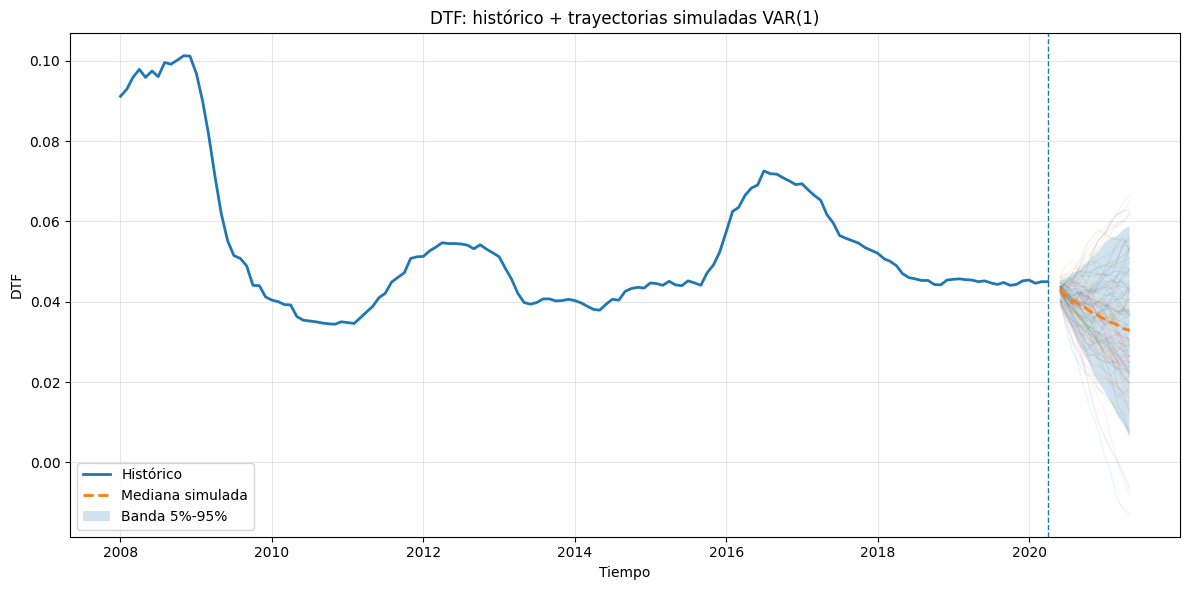

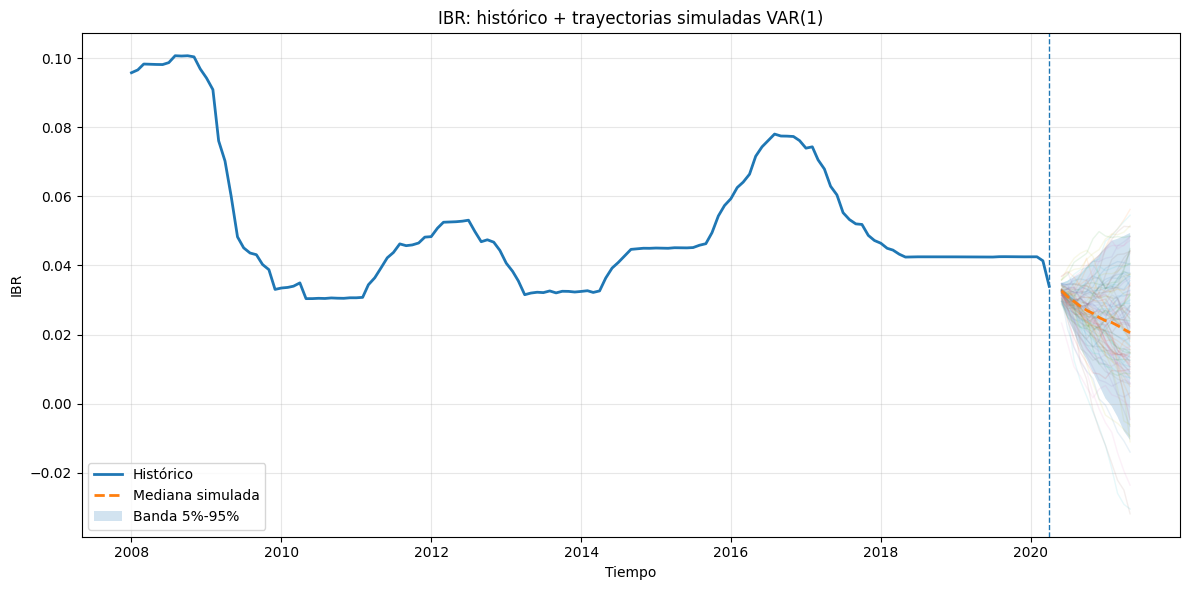

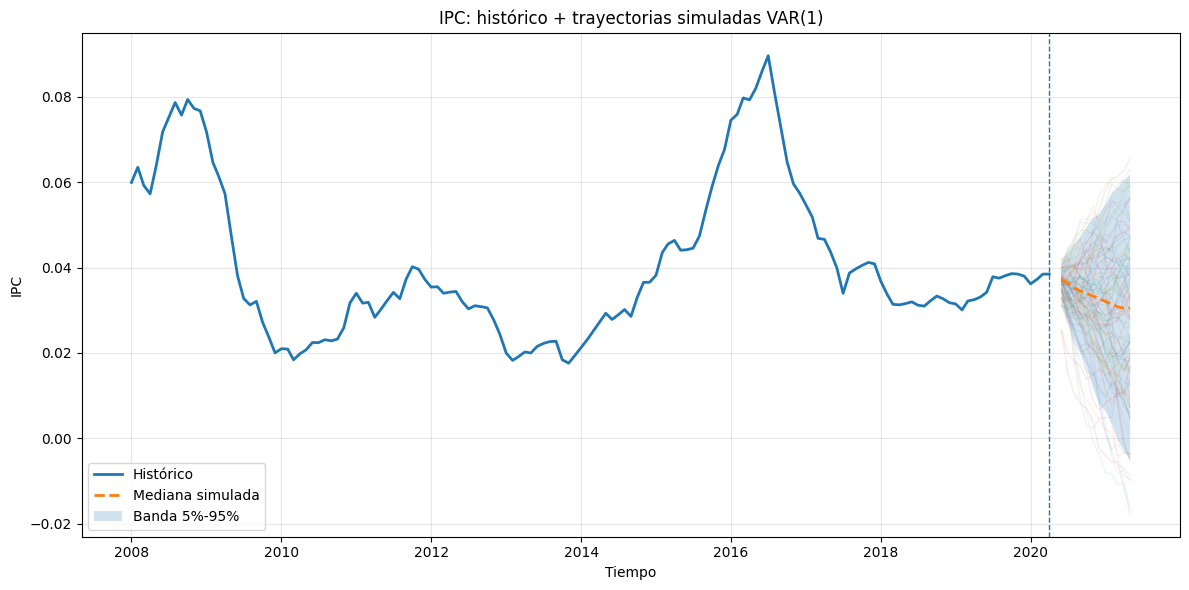

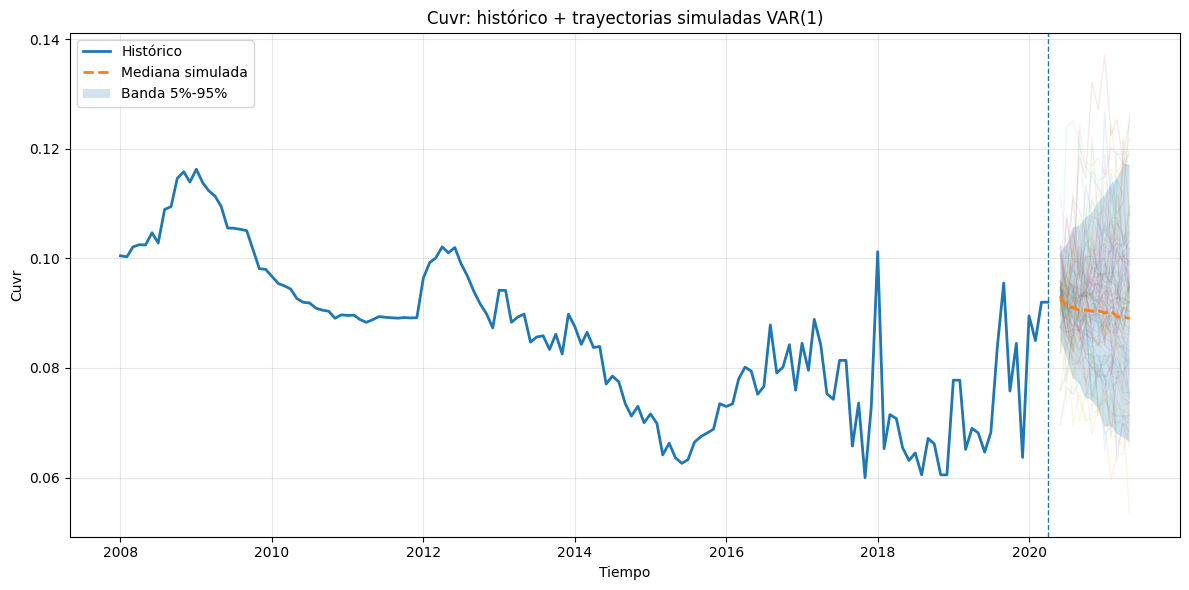

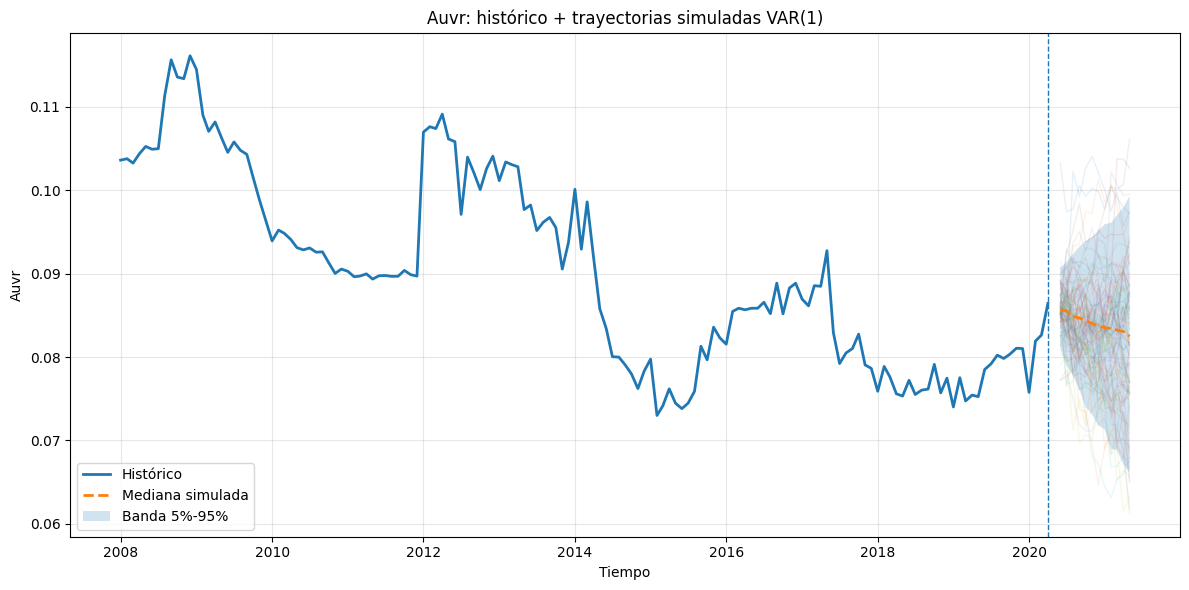

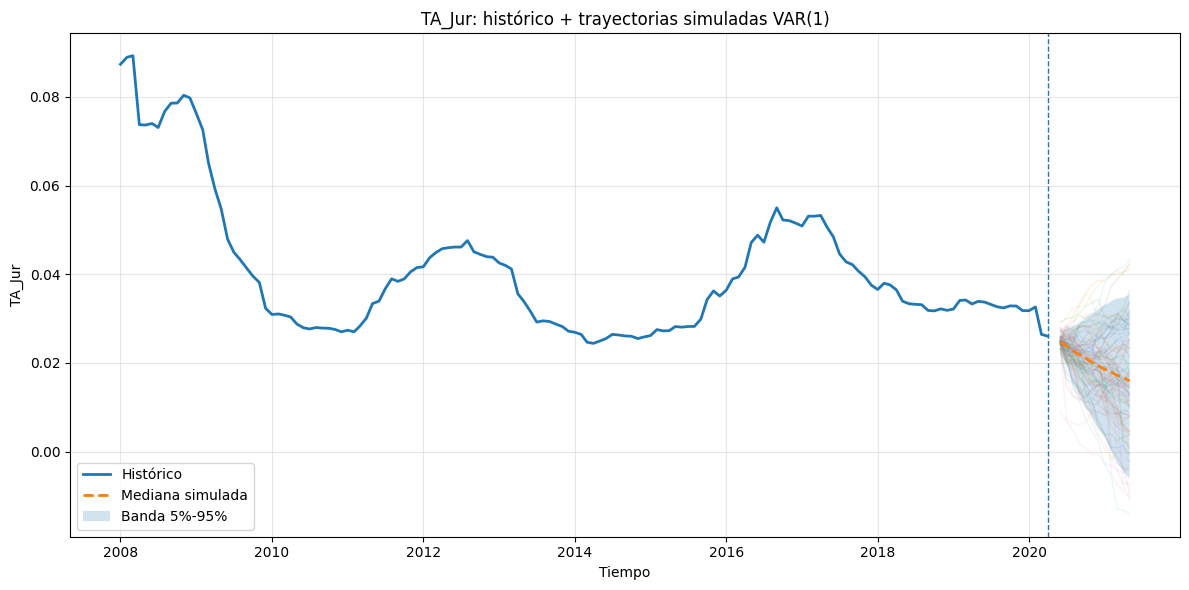

In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 0. CONFIGURACIÓN
# =========================================================
RUTA_FACTOR_RIESGO = "/content/drive/MyDrive/Portafolio/Prueba_1/data/Factores de Riesgo.xlsx"
RUTA_ESCENARIOS = "/content/drive/MyDrive/Portafolio/Prueba_1/data/simulacion_VAR_bootstrap/escenarios_VAR_bootstrap_long.parquet"

FACTOR_COLS = ['DTF', 'IBR', 'IPC', 'Cuvr', 'Auvr', 'TA_Jur']

N_TRAYECTORIAS_MOSTRAR = 100

GUARDAR_GRAFICAS = True
CARPETA_GRAFICAS = "/content/drive/MyDrive/Portafolio/Prueba_1/data/simulacion_VAR_bootstrap/graficas_trayectorias"
os.makedirs(CARPETA_GRAFICAS, exist_ok=True)


# =========================================================
# 1. FUNCIÓN ROBUSTA PARA CONVERTIR FECHAS
# =========================================================
def convertir_fecha_excel(serie):
    """
    Convierte una serie de fechas que puede venir como:
    - datetime
    - string
    - serial de Excel
    """
    s = serie.copy()

    # Si ya es datetime, devolver
    if pd.api.types.is_datetime64_any_dtype(s):
        return pd.to_datetime(s, errors="coerce")

    # Intentar conversión numérica
    s_num = pd.to_numeric(s, errors="coerce")

    # Si hay suficientes valores numéricos, asumimos serial Excel
    if s_num.notna().sum() > 0:
        return pd.to_datetime(s_num, unit="D", origin="1899-12-30", errors="coerce")

    # Si no, intentar parseo normal
    return pd.to_datetime(s, errors="coerce")


# =========================================================
# 2. CARGAR HISTÓRICO
# =========================================================
factor_riesgo = pd.read_excel(RUTA_FACTOR_RIESGO)

df = factor_riesgo.copy()
df = df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed")]

# Detectar columna fecha
fecha_col = None
for c in df.columns:
    if str(c).strip().lower() == "fecha":
        fecha_col = c
        break

if fecha_col is not None:
    df[fecha_col] = convertir_fecha_excel(df[fecha_col])
    df = df.sort_values(fecha_col).reset_index(drop=True)

X = df[FACTOR_COLS].apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

# Alinear fechas con X
if fecha_col is not None and df[fecha_col].notna().sum() >= len(X):
    fechas_hist = df.loc[X.index, fecha_col].reset_index(drop=True)
else:
    fechas_hist = pd.RangeIndex(start=1, stop=len(X) + 1)

print("Primeras fechas históricas:")
print(fechas_hist[:5])


# =========================================================
# 3. CARGAR ESCENARIOS
# =========================================================
escenarios_long = pd.read_parquet(RUTA_ESCENARIOS)

# =========================================================
# 4. CONSTRUIR FECHAS FUTURAS
# =========================================================
# Si ya vienen guardadas y están bien, se usan.
# Si no, se construyen a partir de la última fecha histórica.
if "fecha_futura" in escenarios_long.columns:
    try:
        fechas_futuras = pd.to_datetime(escenarios_long["fecha_futura"].unique(), errors="coerce")
        fechas_futuras = sorted(pd.Series(fechas_futuras).dropna().unique())
    except:
        fechas_futuras = None
else:
    fechas_futuras = None

if fechas_futuras is None or len(fechas_futuras) == 0:
    if isinstance(fechas_hist.iloc[-1], pd.Timestamp):
        fechas_futuras = pd.date_range(
            start=fechas_hist.iloc[-1] + pd.offsets.MonthEnd(1),
            periods=int(escenarios_long["horizonte"].max()),
            freq="M"
        )
    else:
        fechas_futuras = list(range(len(X) + 1, len(X) + int(escenarios_long["horizonte"].max()) + 1))


# =========================================================
# 5. GRAFICAR HISTÓRICO + TRAYECTORIAS
# =========================================================
escenarios_disponibles = np.sort(escenarios_long["escenario"].unique())
n_mostrar = min(N_TRAYECTORIAS_MOSTRAR, len(escenarios_disponibles))
np.random.seed(123)
escenarios_mostrar = np.random.choice(escenarios_disponibles, size=n_mostrar, replace=False)

for factor in FACTOR_COLS:
    plt.figure(figsize=(12, 6))

    # Serie histórica
    plt.plot(
        fechas_hist,
        X[factor].values,
        linewidth=2,
        label="Histórico"
    )

    # Trayectorias simuladas
    for esc in escenarios_mostrar:
        sub = escenarios_long[escenarios_long["escenario"] == esc].sort_values("horizonte")
        plt.plot(
            fechas_futuras,
            sub[factor].values,
            alpha=0.10,
            linewidth=1
        )

    # Banda percentílica
    resumen_factor = (
        escenarios_long
        .groupby("horizonte")[factor]
        .agg(
            p5=lambda x: np.quantile(x, 0.05),
            p50=lambda x: np.quantile(x, 0.50),
            p95=lambda x: np.quantile(x, 0.95)
        )
        .reset_index()
    )

    plt.plot(
        fechas_futuras,
        resumen_factor["p50"].values,
        linestyle="--",
        linewidth=2,
        label="Mediana simulada"
    )

    plt.fill_between(
        fechas_futuras,
        resumen_factor["p5"].values,
        resumen_factor["p95"].values,
        alpha=0.2,
        label="Banda 5%-95%"
    )

    # Línea de corte historia/simulación
    plt.axvline(
        x=fechas_hist.iloc[-1] if hasattr(fechas_hist, "iloc") else fechas_hist[-1],
        linestyle="--",
        linewidth=1
    )

    plt.title(f"{factor}: histórico + trayectorias simuladas VAR(1)")
    plt.xlabel("Tiempo")
    plt.ylabel(factor)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if GUARDAR_GRAFICAS:
        ruta_fig = os.path.join(CARPETA_GRAFICAS, f"{factor}_historico_trayectorias.png")
        plt.savefig(ruta_fig, dpi=300, bbox_inches="tight")

    plt.show()